## Analyse du jeu de données

In [3]:
#import kagglehub
#import clean_df
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

In [4]:
data = pd.read_csv("games.csv")

In [5]:
data.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [6]:
data.describe()

,AppID,Peak CCU,Required age,Price,Discount,DLC count,Metacritic score,User score,Positive,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Movies
count,1.226110e+05,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,40.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,122611.000000,0.0
mean,1.985386e+06,5.459332e+01,0.167611,4.765091,18.353663,0.545856,2.564941,0.024549,1.044986e+03,1.691974e+02,99.175000,18.087015,9.618250e+02,2.080232e+02,13.789268,1.735705e+02,14.722170,NaN
std,1.087595e+06,3.729452e+03,1.653591,12.531030,28.858970,14.516026,13.660559,1.394901,2.809173e+04,5.374645e+03,0.675107,141.493879,2.187880e+04,1.121768e+04,270.378053,1.120254e+04,294.509615,NaN
min,1.000000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
25%,1.063175e+06,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,99.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
50%,1.907380e+06,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,99.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
75%,2.869560e+06,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,100.000000,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
max,4.264350e+06,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,100.000000,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,NaN


In [7]:
n_duplicated = data.duplicated().sum()
print(f"Number of duplicated rows: {n_duplicated}\n")

df = pd.DataFrame({
    'n_unique':data.nunique(),
    'n_missing':data.isna().sum(),
    'missing_ratio':data.isna().mean(),
    'dtype':data.dtypes.values
})

Number of duplicated rows: 0



In [8]:
display(
    df.style.background_gradient(cmap='BuPu')
        .format({"missing_ratio": "{:.2%}"})
)

,n_unique,n_missing,missing_ratio,dtype
AppID,122611,0,0.00%,int64
Name,121454,1,0.00%,object
Release date,5081,0,0.00%,object
Estimated owners,14,0,0.00%,object
Peak CCU,1110,0,0.00%,int64
Required age,15,0,0.00%,int64
Price,941,0,0.00%,float64
Discount,88,0,0.00%,int64
DLC count,117,0,0.00%,int64
About the game,113556,8449,6.89%,object


In [9]:
data2=data.drop(columns=["Movies","Screenshots","Metacritic url","Header image","AppID","Website","Notes"])
data2['About the game'] = data2['About the game'] != ""      #).astype(int) pour quant
data2['Support email'] = data2['Support email'] != ""
data2['Support url'] = data2['Support url'] != ""
data2['Release date'] = data2['Release date'].str[-4:]

# Fonction qui va compter le nombre d'avis dans chaque ligne
def count_reviews(row):
    if isinstance(row, str):
        reviews = re.findall(r'"([^"]*)"', row) 
        return len(reviews)
    else:
        return 0 

data2['Reviews'] = data2['Reviews'].apply(count_reviews)

display(
    data2.head().style.background_gradient(cmap="BuPu")
)

/home/plisson-treh/Bureau/TP Analyse de données/Exploration/.venv/lib/python3.11/site-packages/pandas/io/formats/style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/home/plisson-treh/Bureau/TP Analyse de données/Exploration/.venv/lib/python3.11/site-packages/pandas/io/formats/style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Support url,Support email,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
0,Black Dragon Mage Playtest,2023,0 - 0,0,0,0.000000,0,0,True,[],[],0,True,True,True,False,False,0,0,0,0,nan,0,0,0,0,0,0,nan,nan,nan,nan,nan
1,Supipara - Chapter 1 Spring Has Come!,2016,0 - 20000,0,0,5.240000,65,0,True,['English'],[],0,True,True,True,False,False,0,0,252,3,nan,0,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sharing",Adventure,"Adventure,Visual Novel,Anime,Cute"
2,Mystery Solitaire The Black Raven,2019,0 - 20000,0,0,4.990000,0,0,True,"['English', 'French', 'German', 'Russian']",[],0,True,True,True,True,False,0,0,21,3,nan,0,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,Tutorial,Singleplayer,Tabletop"
3,버튜버 파라노이아 - Vtuber Paranoia,2024,0 - 20000,1,0,8.990000,0,1,True,['Korean'],['Korean'],0,True,True,True,False,False,0,0,0,0,nan,19,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",nan
4,Maze Quest VR,2025,0 - 20000,0,0,4.990000,0,0,True,['English'],['English'],0,True,True,True,False,False,0,0,0,0,nan,0,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing","Action,Early Access",nan


In [10]:
data2.loc[data2["Name"].duplicated()]

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
1179,Shadow of the Tomb Raider: Definitive Edition,2018,0 - 20000,0,17,4.00,90,0,True,"['English', 'French', 'Italian', 'German', 'Sp...",...,66724,0,0,0,0,"Eidos-Montréal,Crystal Dynamics,Nixxes,Feral I...","Crystal Dynamics,Feral Interactive (Mac),Feral...","Single-player,Steam Achievements,Full controll...","Action,Adventure","Adventure,Action,Lara Croft,Female Protagonist..."
1608,Shadow of the Tomb Raider: Definitive Edition,2018,2000000 - 5000000,582,17,4.00,90,0,True,"['English', 'French', 'Italian', 'German', 'Sp...",...,66725,1270,304,790,265,"Eidos-Montréal,Crystal Dynamics,Nixxes,Feral I...","Crystal Dynamics,Feral Interactive (Mac),Feral...","Single-player,Steam Achievements,Full controll...","Action,Adventure","Adventure,Action,Female Protagonist,Singleplay..."
2411,Last Stop,2023,0 - 20000,0,0,12.99,0,0,True,['English'],...,0,0,0,0,0,Tainted Games,Tainted Games,"Single-player,Steam Achievements,Full controll...","Action,Adventure,Indie","Action,Adventure,Puzzle,Walking Simulator,FPS,..."
3621,Shadow of the Tomb Raider: Definitive Edition,2018,0 - 20000,0,17,4.00,90,0,True,"['English', 'French', 'Italian', 'German', 'Sp...",...,66731,0,0,0,0,"Eidos-Montréal,Crystal Dynamics,Nixxes,Feral I...","Crystal Dynamics,Feral Interactive (Mac),Feral...","Single-player,Steam Achievements,Full controll...","Action,Adventure","Adventure,Action,Lara Croft,Female Protagonist..."
3934,LUNA,2020,50000 - 100000,0,0,0.74,0,0,True,"['English', 'Korean', 'Japanese', 'Simplified ...",...,287,0,0,0,0,Simple,PsychoFlux Entertainment,"Single-player,Steam Achievements,Steam Cloud,F...","Adventure,Casual,Indie,RPG","Puzzle,Female Protagonist,RPG,2D,Top-Down,Horr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122496,FALL,2026,0 - 0,0,0,1.19,0,0,True,['English'],...,0,0,0,0,0,Wise In A Well,Wise In A Well,"Single-player,Custom Volume Controls,Mouse Onl...","Action,Casual,Indie",NaN
122530,Sycophant,2025,0 - 0,0,0,34.99,0,0,True,['Simplified Chinese'],...,0,0,0,0,0,Fractious,Fractious,"Single-player,Family Sharing","Casual,RPG",NaN
122557,Conquest,2026,0 - 0,0,0,3.99,0,0,True,['English'],...,0,0,0,0,0,Zellgert Games,Zellgert Games,"Single-player,Steam Achievements,Camera Comfor...","Adventure,Indie,RPG",NaN
122561,Space Aces,2026,0 - 0,0,0,0.00,0,0,True,['English'],...,0,0,0,0,0,DewEnforcer,Space Aces,"Multi-player,MMO,PvP,Online PvP,Co-op,Online C...","Action,Casual,Massively Multiplayer,Free To Play",NaN


In [12]:
data3 = data2.dropna(subset=['Genres', 'Categories'])
data3 = (data3.sort_values('Peak CCU', ascending=False)
        .drop_duplicates(subset=['Name', 'Developers', 'Release date'], keep='first'))
data3.loc[data3["Name"] == "Space Aces"]

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
122561,Space Aces,2026,0 - 0,0,0,0.0,0,0,True,['English'],...,0,0,0,0,0,DewEnforcer,Space Aces,"Multi-player,MMO,PvP,Online PvP,Co-op,Online C...","Action,Casual,Massively Multiplayer,Free To Play",NaN
1604,Space Aces,2022,0 - 0,0,0,0.0,0,0,True,['English'],...,0,0,0,0,0,"Matthew Hubbs,Austin Brooks,Bradley Vanderzalm...",Matthew Hubbs,"Single-player,Partial Controller Support","Action,Indie,Simulation",NaN


In [13]:
qual = data3.select_dtypes(exclude='int64')
quant = data3.select_dtypes(include='int64')
display(qual.head())
display(quant.head())

,Name,Release date,Estimated owners,Price,About the game,Supported languages,Full audio languages,Support url,Support email,Windows,Mac,Linux,Score rank,Developers,Publishers,Categories,Genres,Tags
45509,Counter-Strike 2,2012,100000000 - 200000000,0.00,True,"['Czech', 'Danish', 'Dutch', 'English', 'Finni...","['English', 'Indonesian']",True,True,True,False,True,NaN,Valve,Valve,"Multi-player,Cross-Platform Multiplayer,Steam ...","Action,Free To Play","FPS,Shooter,Multiplayer,Competitive,Action,Tea..."
4193,Dota 2,2013,100000000 - 200000000,0.00,True,"['Bulgarian', 'Czech', 'Danish', 'Dutch', 'Eng...","['English', 'Korean', 'Simplified Chinese', 'V...",True,True,True,True,True,NaN,Valve,Valve,"Multi-player,Co-op,Steam Trading Cards,Steam W...","Action,Strategy,Free To Play","Free to Play,MOBA,Multiplayer,Strategy,e-sport..."
8878,PUBG: BATTLEGROUNDS,2017,100000000 - 200000000,0.00,True,"['English', 'Korean', 'Simplified Chinese', 'F...",[],True,True,True,False,False,NaN,PUBG Corporation,"KRAFTON, Inc.","Multi-player,PvP,Online PvP,Stats,Remote Play ...","Action,Adventure,Massively Multiplayer,Free To...","Survival,Shooter,Battle Royale,Multiplayer,FPS..."
104347,Bongo Cat,2025,0 - 20000,0.00,True,"['English', 'German', 'Dutch', 'Japanese', 'Ko...",[],True,True,True,False,False,NaN,"Marcel Zurawka,Julius Krüger",Irox Games,"Single-player,Multi-player,Co-op,Online Co-op,...","Casual,Indie,Massively Multiplayer,Simulation,...",NaN
17581,ELDEN RING NIGHTREIGN,2025,2000000 - 5000000,29.99,True,"['English', 'Japanese', 'French', 'Italian', '...","['English', 'Traditional Chinese']",True,True,True,False,False,NaN,"FromSoftware, Inc.","FromSoftware, Inc.,Bandai Namco Entertainment","Single-player,Multi-player,Co-op,Online Co-op,...","Action,RPG","Souls-like,Online Co-Op,Rogue-like,Multiplayer..."


,Peak CCU,Required age,Discount,DLC count,Reviews,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks
45509,1013936,0,0,1,0,0,0,7642084,1173003,1,4830455,33906,702,6237,307
4193,623941,0,0,2,0,90,0,2037143,461826,0,14369,54064,1427,1155,860
8878,314682,13,0,0,0,0,0,1520457,1037487,37,1753261,23787,730,6082,302
104347,164168,0,0,0,0,0,0,0,0,7,0,33409,7434,2225,4891
17581,163599,17,25,1,0,0,0,48901,16771,37,114052,4138,857,2242,432


In [14]:
#clean=clean_df.clean()

In [15]:
total_count=len(data)
print(total_count)

122611


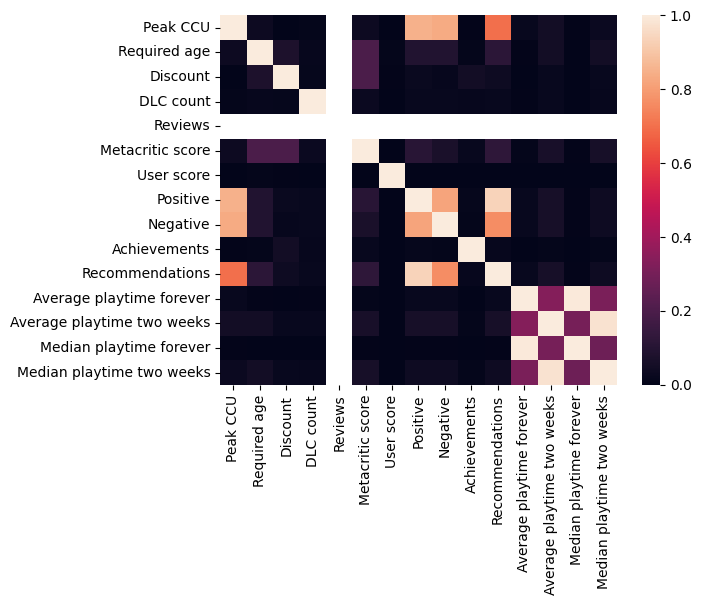

In [16]:
corr=quant.corr()
sns.heatmap(corr)
plt.show()

111896 1222


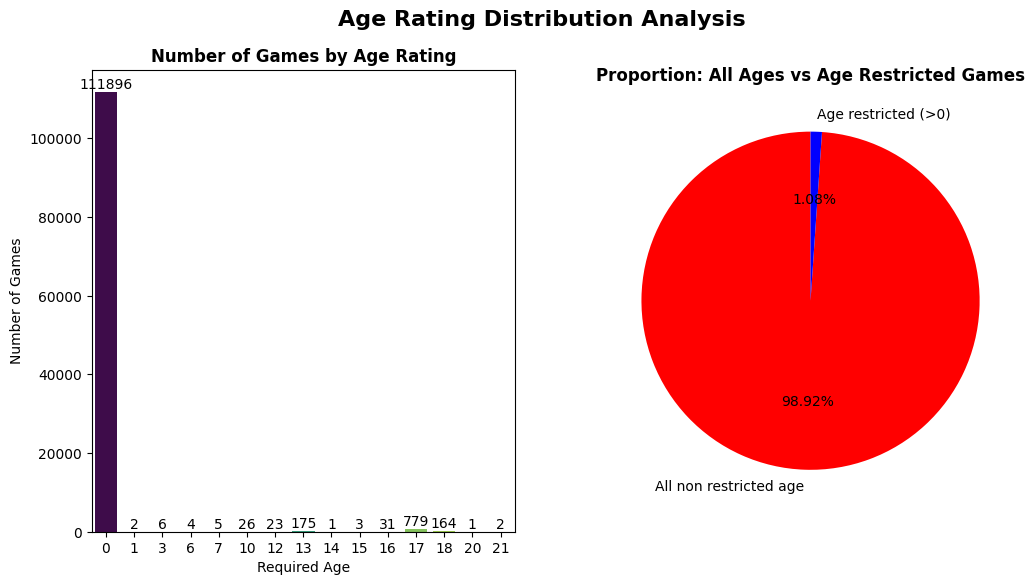

In [20]:
fig=plt.figure(figsize=(12,6))
fig.suptitle('Age Rating Distribution Analysis', fontsize=16, fontweight='bold')

ax1=plt.subplot(1,2,1)
age_order = sorted(data3['Required age'].unique())
sns.countplot(data=data3, x='Required age', palette='viridis', order=age_order, hue=data3['Required age'], legend=False)
ax1.set_title('Number of Games by Age Rating', fontweight='bold')
ax1.set_xlabel('Required Age')
ax1.set_ylabel('Number of Games')

for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom'
    )

age_0_count = (data3['Required age'] == 0).sum()
age_above_0_count = (data3['Required age'] > 0).sum()
print(age_0_count,age_above_0_count)
labels = ['All non restricted age', 'Age restricted (>0)']
sizes = [age_0_count, age_above_0_count]
colors = ['red', 'blue']

ax2=plt.subplot(1,2,2)
ax2.pie(sizes, labels=labels, autopct='%1.2f%%', colors=colors, startangle=90)
ax2.set_title('Proportion: All Ages vs Age Restricted Games', fontweight='bold')

plt.show()

The large majority of the games don't require a specific age to play

=== Analysis of Game Price Distribution===
Total number of games: 113,118
Free games: 17,606 (15.6%)
Paid Games: 95,512 (84.4%)
Average price: $5.04
Median price: $2.74
Minimum price: $0.00
Maximum price: $999.98
Standard deviation: $12.76


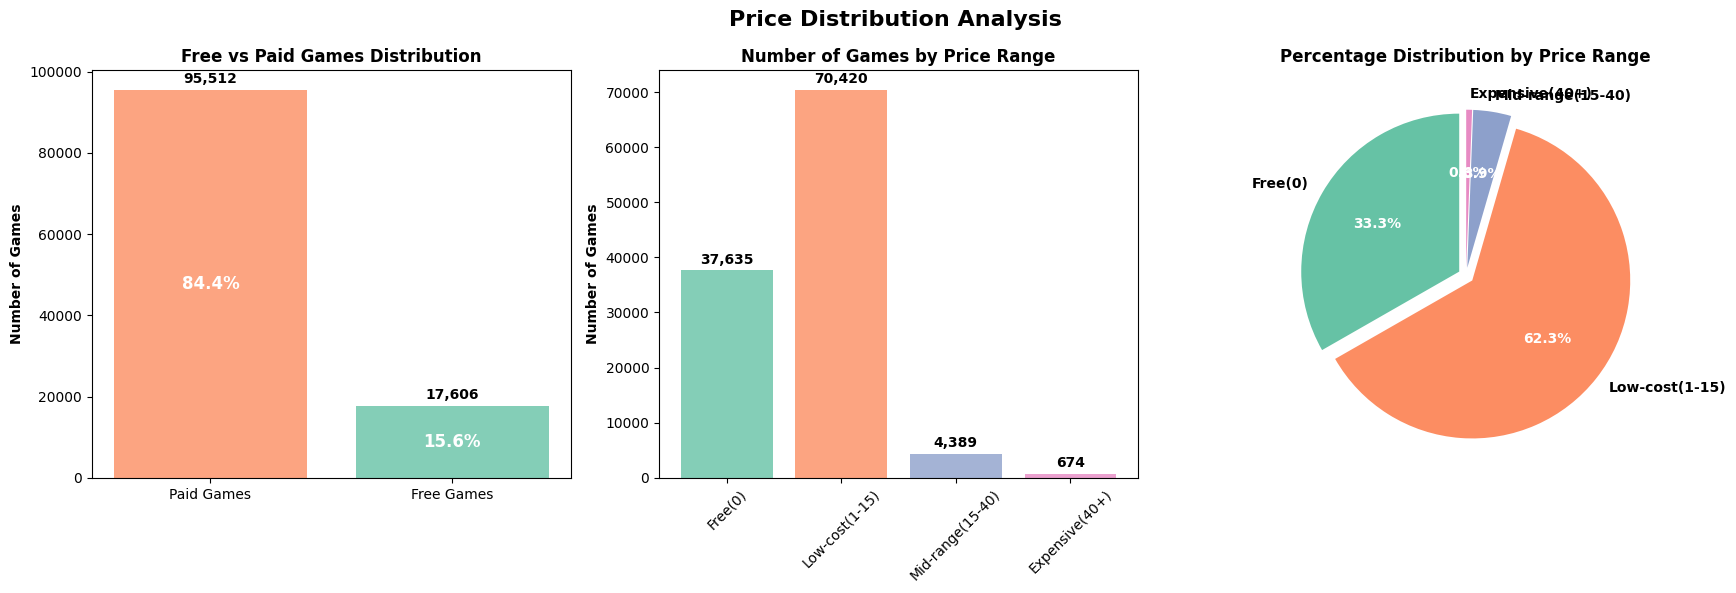

In [21]:
data3['price_category'] = data3['Price'].apply(lambda x: 'Free Games' if x == 0 else 'Paid Games')
free_count = (data3['Price'] == 0).sum()
paid_count = (data3['Price'] > 0).sum()
total_count = len(data3)
free_percentage = (free_count / total_count) * 100
paid_percentage = (paid_count / total_count) * 100
print("=== Analysis of Game Price Distribution===")
print(f"Total number of games: {total_count:,}")
print(f"Free games: {free_count:,} ({free_percentage:.1f}%)")
print(f"Paid Games: {paid_count:,} ({paid_percentage:.1f}%)")
print(f"Average price: ${data3['Price'].mean():.2f}")
print(f"Median price: ${data3['Price'].median():.2f}")
print(f"Minimum price: ${data3['Price'].min():.2f}")
print(f"Maximum price: ${data3['Price'].max():.2f}")
print(f"Standard deviation: ${data3['Price'].std():.2f}")

bins = [-1, 1, 15, 40, float('inf')]
labels = ['Free(0)', 'Low-cost(1-15)', 'Mid-range(15-40)', 'Expensive(40+)']
data3['price_range'] = pd.cut(data3['Price'], bins=bins, labels=labels)
price_distribution = data3['price_range'].value_counts().sort_index()
price_percentage = data3['price_range'].value_counts(normalize=True).sort_index() * 100

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Price Distribution Analysis', fontsize=16, fontweight='bold')

colors1 = ['#fc8d62','#66c2a5']
categories = ['Paid Games', 'Free Games']
counts = [paid_count, free_count]
percentages = [paid_percentage, free_percentage]
bars1 = ax1.bar(categories, counts, color=colors1, alpha=0.8)
ax1.set_title('Free vs Paid Games Distribution', fontweight='bold')
ax1.set_ylabel('Number of Games', fontweight='bold')

for i, (bar, count, percentage) in enumerate(zip(bars1, counts, percentages)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height/2, 
             f'{percentage:.1f}%', ha='center', va='center', 
             fontweight='bold', fontsize=12, color='white')
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01, 
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

colors2 = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
bars2 = ax2.bar(price_distribution.index, price_distribution.values, color=colors2, alpha=0.8)
ax2.set_title('Number of Games by Price Range', fontweight='bold')
ax2.set_ylabel('Number of Games', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)


for i, (bar, count) in enumerate(zip(bars2, price_distribution.values)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(price_distribution.values)*0.01, 
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

explode = (0.05, 0.05, 0.05, 0.05)
wedges, texts, autotexts = ax3.pie(price_percentage.values, 
                                   labels=price_percentage.index, 
                                   autopct='%1.1f%%',
                                   colors=colors2,
                                   explode=explode,
                                   startangle=90)

plt.setp(autotexts, size=10, weight="bold", color='white')
plt.setp(texts, size=10, weight="bold")
ax3.set_title('Percentage Distribution by Price Range', fontweight='bold')
ax3.axis('equal')
plt.tight_layout()
plt.show()

Most games ave very cheap or even free, it may be due to a tendency of players to buy expensive games only when these are famous or from well-known developers team (we might discuss it later with the AAA games analysis)

Sales range distribution statistics:
0 - 20000           :  74539 games |  65.9%
0 - 0               :  13203 games |  11.7%
20000 - 50000       :  11332 games |  10.0%
50000 - 100000      :   5313 games |   4.7%
100000 - 200000     :   3424 games |   3.0%
200000 - 500000     :   2834 games |   2.5%
500000 - 1000000    :   1142 games |   1.0%
1000000 - 2000000   :    717 games |   0.6%
2000000 - 5000000   :    398 games |   0.4%
5000000 - 10000000  :    122 games |   0.1%
10000000 - 20000000 :     50 games |   0.0%
20000000 - 50000000 :     31 games |   0.0%
50000000 - 100000000:      9 games |   0.0%
100000000 - 200000000:      4 games |   0.0%


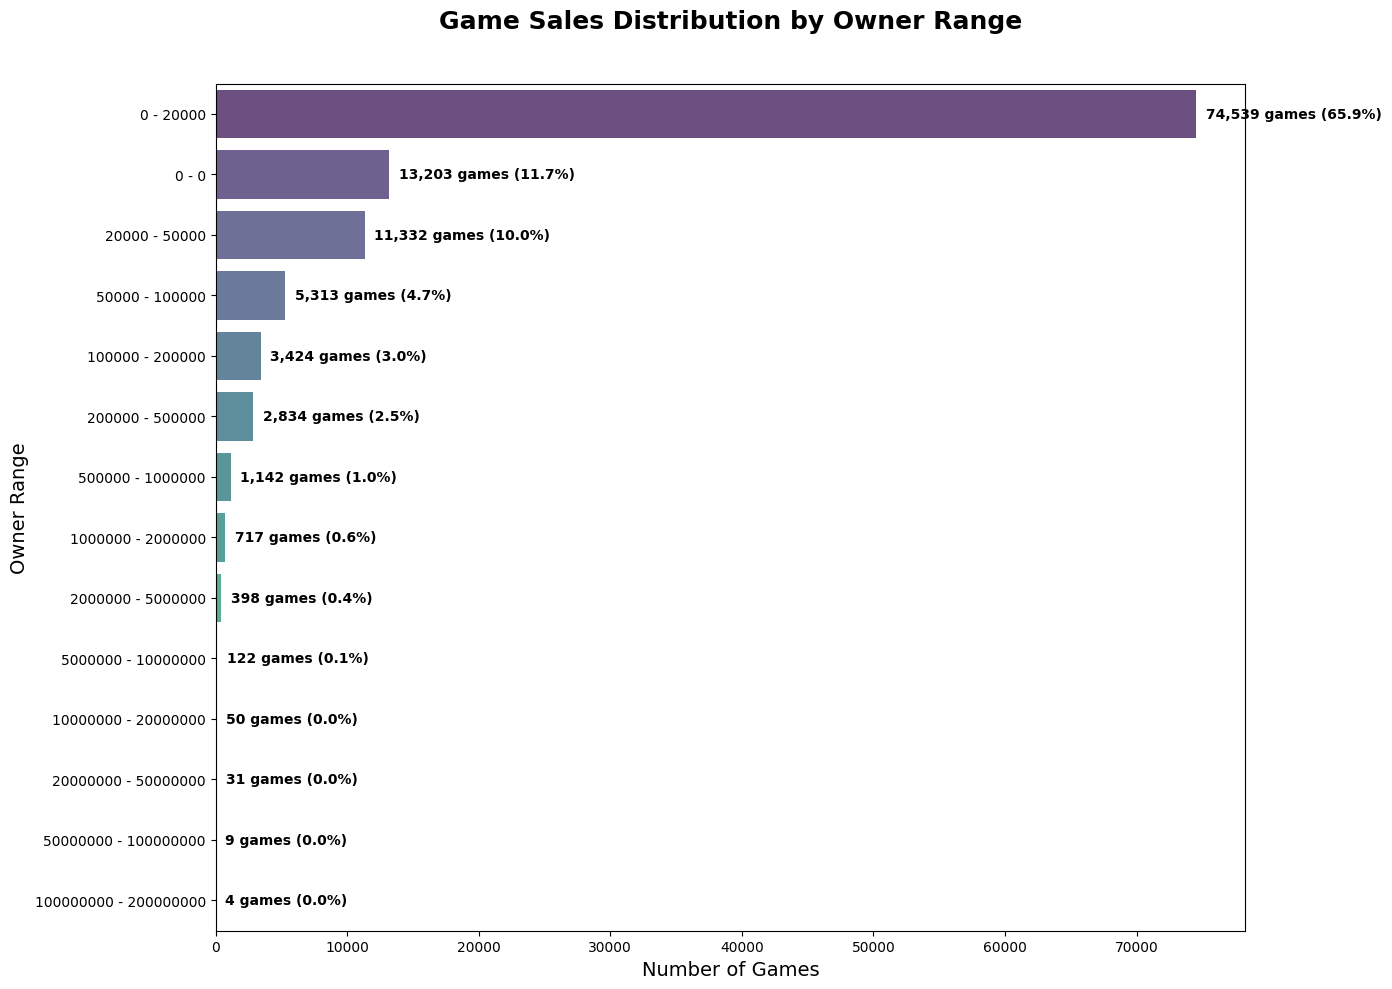

In [22]:
owner_distribution = data3['Estimated owners'].value_counts()
owner_percentage = data3['Estimated owners'].value_counts(normalize=True) * 100
owner_distribution_sorted = owner_distribution.sort_values(ascending=False)
owner_percentage_sorted = owner_percentage[owner_distribution_sorted.index]
print("Sales range distribution statistics:")
for owner_range, count in owner_distribution_sorted.items():
    percentage = owner_percentage[owner_range]
    print(f"{owner_range:20}: {count:>6} games | {percentage:>5.1f}%")

plt.figure(figsize=(14, 10))
colors = sns.color_palette("viridis", len(owner_distribution_sorted))

barplot = sns.barplot(x=owner_distribution_sorted.values, 
                     y=owner_distribution_sorted.index,
                     palette=colors, alpha=0.8,hue=owner_distribution_sorted.index,legend=False)

plt.title('Game Sales Distribution by Owner Range\n', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Number of Games', fontsize=14)
plt.ylabel('Owner Range', fontsize=14)

for i, (count, owner_range) in enumerate(zip(owner_distribution_sorted.values, owner_distribution_sorted.index)):
    percentage = owner_percentage[owner_range]
    plt.text(count + max(owner_distribution_sorted.values)*0.01, i, 
             f'{count:,} games ({percentage:.1f}%)', 
             ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

Only a few famous games are owned by many players, in the majority, games are only owned by tens of thousand of players and there still are few games that don't have any owners.

=== Achievement Count Basic Statistics ===
Total games: 113,118
Games without achievements: 50,861
Games with achievements: 62,257

Achievement count descriptive stats:
count    113118.000000
mean         19.395852
std         146.966642
min           0.000000
25%           0.000000
50%           5.000000
75%          20.000000
max        9821.000000
Name: Achievements, dtype: float64


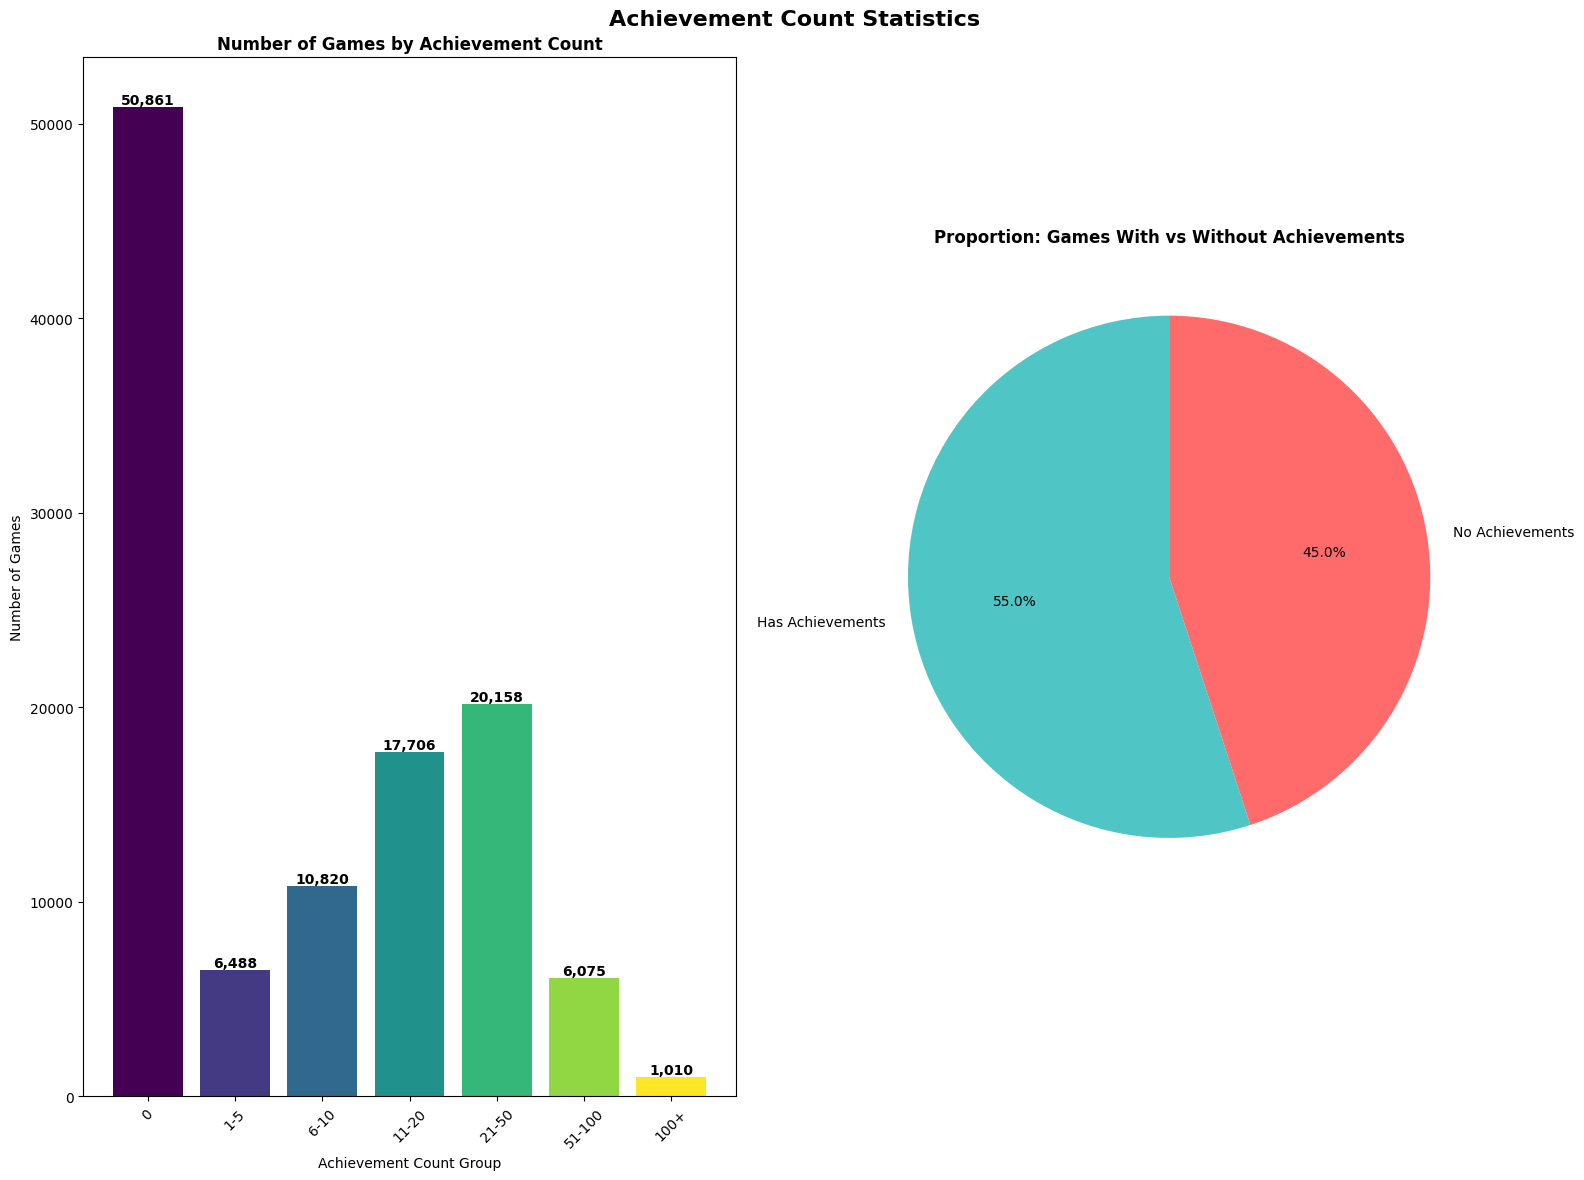


=== Average Values by Achievement Group ===
                   Price  Metacritic score  Recommendations  Positive  \
achievement_group                                                       
0                   4.75              1.21           225.59    325.41   
1-5                 4.01              0.30           919.28   1357.24   
6-10                6.39              0.78           129.93    161.80   
11-20               4.19              2.79           489.10    570.82   
21-50               5.90              6.35          1852.49   1903.48   
51-100              5.81              7.83          4841.90   5183.98   
100+                5.13             11.71         14641.70  18043.43   

                   Average playtime forever  
achievement_group                            
0                                    176.75  
1-5                                   46.07  
6-10                                  93.33  
11-20                                247.94  
21-50                

In [23]:
print("=== Achievement Count Basic Statistics ===")
print(f"Total games: {len(data3):,}")
print(f"Games without achievements: {(data3['Achievements'] == 0).sum():,}")
print(f"Games with achievements: {(data3['Achievements'] > 0).sum():,}")

print("\nAchievement count descriptive stats:")
print(data3['Achievements'].describe())

data3['achievement_group'] = pd.cut(
    data3['Achievements'],
    bins=[-1, 0, 5, 10, 20, 50, 100, 10000],
    labels=['0', '1-5', '6-10', '11-20', '21-50', '51-100', '100+']
)

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(16, 12))
fig.suptitle('Achievement Count Statistics', fontsize=16, fontweight='bold')

group_order = ['0', '1-5', '6-10', '11-20', '21-50', '51-100', '100+']
group_counts = data3['achievement_group'].value_counts().reindex(group_order)

bars = ax1.bar(group_order, group_counts, color=plt.cm.viridis(np.linspace(0, 1, len(group_order))))
ax1.set_title('Number of Games by Achievement Count', fontweight='bold')
ax1.set_xlabel('Achievement Count Group')
ax1.set_ylabel('Number of Games')
ax1.tick_params(axis='x', rotation=45)

for bar, count in zip(bars, group_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

has_achievements = (data3['Achievements'] > 0).sum()
no_achievements = (data3['Achievements'] == 0).sum()

labels = ['Has Achievements', 'No Achievements']
sizes = [has_achievements, no_achievements]
colors = ['#50c5c5', '#ff6b6b']

ax2.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Proportion: Games With vs Without Achievements', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Average Values by Achievement Group ===")
achievement_groups = data3.groupby('achievement_group', observed=False)
group_stats = achievement_groups.agg({
    'Price': 'mean',
    'Metacritic score': 'mean',
    'Recommendations': 'mean',
    'Positive': 'mean',
    'Average playtime forever': 'mean'
}).round(2)

print(group_stats)

We have one chance on two to select a game with possibles achievements, and if it's selected, on average, it will have between ten and fifty
possibles achievements. We see that there seems to be a link between the average time played and the number of possible achievements a game have. We can also point out that the little values of the metacritics score for each group can be explained by the large number of games having a metacritic score of 0.

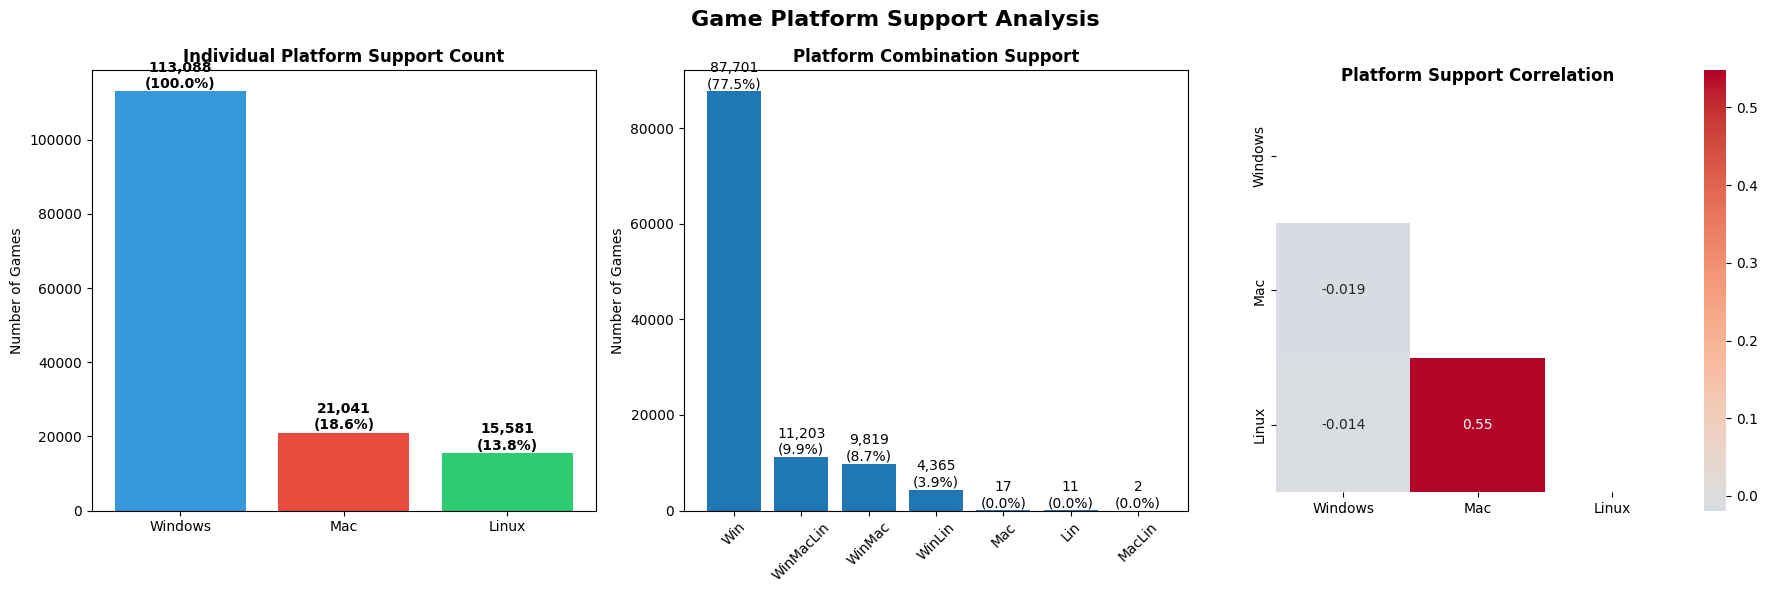

In [24]:
data3['platform_combo'] = data3.apply(lambda x: 
                               f"{'Win' if x['Windows'] else ''}"
                               f"{'Mac' if x['Mac'] else ''}"
                               f"{'Lin' if x['Linux'] else ''}", axis=1)
data3['platform_combo'] = data3['platform_combo'].replace('', 'None')

platform_combo_counts = data3['platform_combo'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Game Platform Support Analysis', fontsize=16, fontweight='bold')

platform_data = {
    'Platform': ['Windows', 'Mac', 'Linux'],
    'Count': [data3['Windows'].sum(), data3['Mac'].sum(), data3['Linux'].sum()],
    'Percentage': [data3['Windows'].mean()*100, data3['Mac'].mean()*100, data3['Linux'].mean()*100]
}

bars = axes[0].bar(platform_data['Platform'], platform_data['Count'], 
                  color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('Individual Platform Support Count', fontweight='bold')
axes[0].set_ylabel('Number of Games')
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 50,
                f'{platform_data["Count"][i]:,}\n({platform_data["Percentage"][i]:.1f}%)',
                ha='center', va='bottom', fontweight='bold')

combo_df = pd.DataFrame({
    'Combination': platform_combo_counts.index,
    'Count': platform_combo_counts.values
})
combo_df = combo_df.sort_values('Count', ascending=False)

bars = axes[1].bar(combo_df['Combination'], combo_df['Count'])
axes[1].set_title('Platform Combination Support', fontweight='bold')
axes[1].set_ylabel('Number of Games')
axes[1].tick_params(axis='x', rotation=45)
for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = (height / len(data3)) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 20,
                f'{height:,}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=10)

platform_corr = data3[['Windows', 'Mac', 'Linux']].corr()
mask = np.triu(np.ones_like(platform_corr, dtype=bool))
sns.heatmap(platform_corr, annot=True, cmap='coolwarm', center=0, 
           square=True, mask=mask, ax=axes[2])
axes[2].set_title('Platform Support Correlation', fontweight='bold')

plt.tight_layout()
plt.show()

Most games are on Windows (normal given the number of Windows user contrary to other types of platform), we can also point out the similarity between Linux and Mac (little number of games on Linux and Mac which make the 2 games being on both of them proportionnaly large)

Total number of games: 113118
Number of games with Metacritic scores: 4185
Percentage of games with scores: 3.70%

Metacritic Score Statistics:
count    4185.000000
mean       73.797372
std        10.287643
min         6.000000
25%        68.000000
50%        75.000000
75%        81.000000
max        97.000000
Name: Metacritic score, dtype: float64


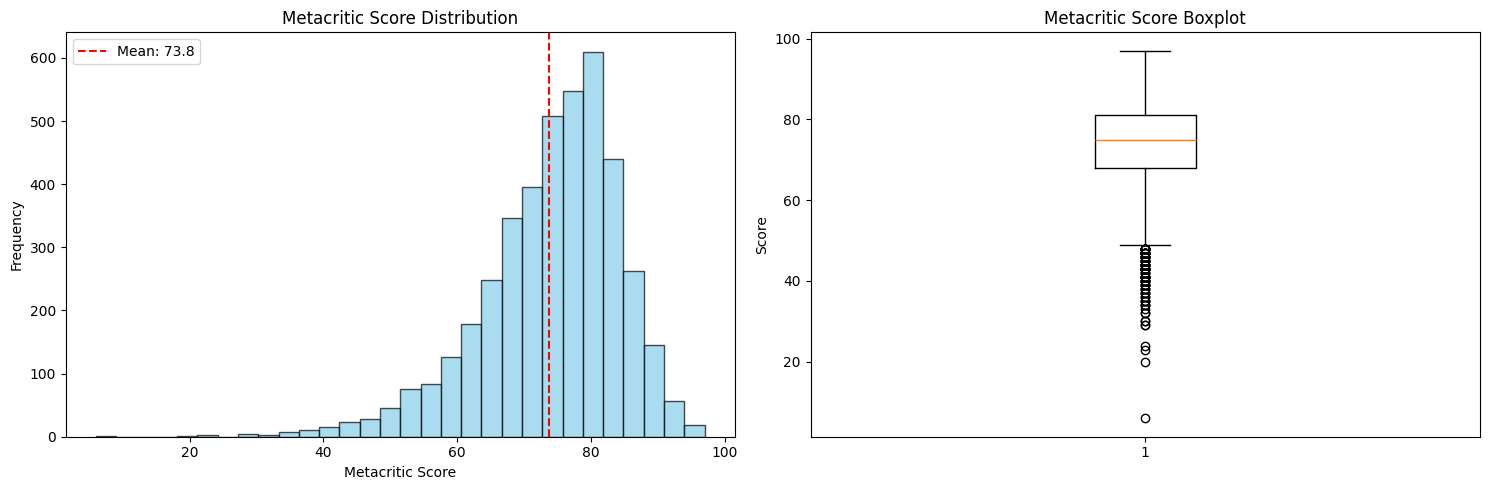

Score Category Distribution:
score_category
Poor (1-59)            391
Fair (60-69)           810
Good (70-79)          1628
Great (80-89)         1242
Excellent (90-100)     114
Name: count, dtype: int64


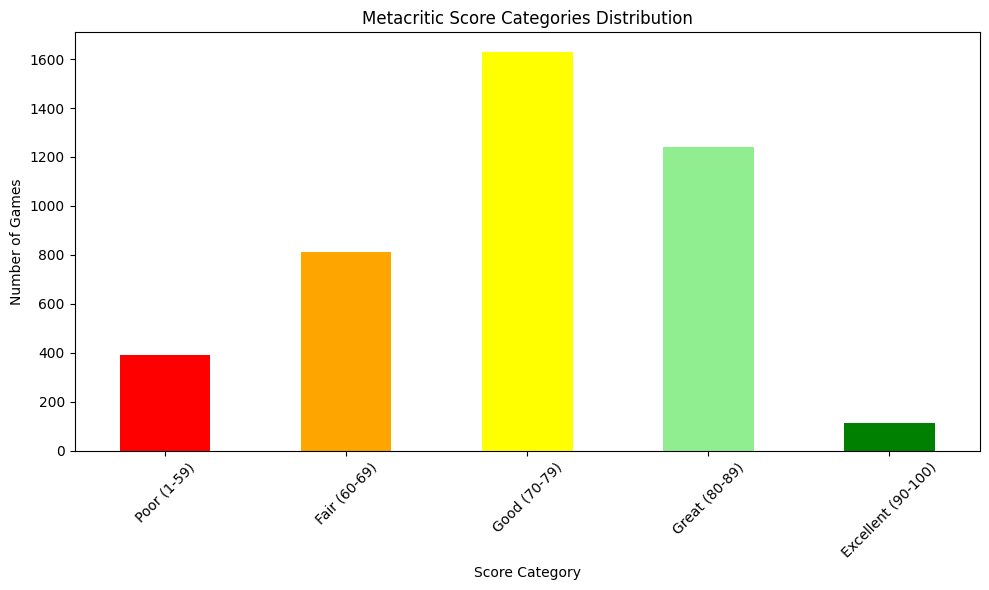


3. Top games:
   Highest Rated Games:
   - Disco Elysium - The Final Cut: 97 points (RPG)
   - Grand Theft Auto V Legacy: 96 points (Action,Adventure)
   - Baldur's Gate 3: 96 points (Adventure,RPG,Strategy)
   - Half-Life 2: 96 points (Action)
   - Half-Life: 96 points (Action)


In [25]:
df_metacritic = data3[data3['Metacritic score'] > 0].copy()

print(f"Total number of games: {len(data3)}")
print(f"Number of games with Metacritic scores: {len(df_metacritic)}")
print(f"Percentage of games with scores: {len(df_metacritic)/len(data3)*100:.2f}%")

print("\nMetacritic Score Statistics:")
print(df_metacritic['Metacritic score'].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df_metacritic['Metacritic score'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Metacritic Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Metacritic Score Distribution')
axes[0].axvline(df_metacritic['Metacritic score'].mean(), color='red', linestyle='--', label=f'Mean: {df_metacritic["Metacritic score"].mean():.1f}')
axes[0].legend()

axes[1].boxplot(df_metacritic['Metacritic score'])
axes[1].set_title('Metacritic Score Boxplot')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

def score_category(score):
    if score >= 90:
        return 'Excellent (90-100)'
    elif score >= 80:
        return 'Great (80-89)'
    elif score >= 70:
        return 'Good (70-79)'
    elif score >= 60:
        return 'Fair (60-69)'
    else:
        return 'Poor (1-59)'
    
df_metacritic['score_category'] = df_metacritic['Metacritic score'].apply(score_category)
score_order = ['Poor (1-59)', 'Fair (60-69)', 'Good (70-79)', 'Great (80-89)', 'Excellent (90-100)']
df_metacritic['score_category'] = pd.Categorical(df_metacritic['score_category'], categories=score_order, ordered=True)
score_dist = df_metacritic['score_category'].value_counts().sort_index()
print("Score Category Distribution:")
print(score_dist)

plt.figure(figsize=(10, 6))
score_dist.plot(kind='bar', color=['red', 'orange', 'yellow', 'lightgreen', 'green'])
plt.title('Metacritic Score Categories Distribution')
plt.xlabel('Score Category')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n3. Top games:")
top_games = df_metacritic.nlargest(5, 'Metacritic score')[['Name', 'Metacritic score', 'Genres']]
print("   Highest Rated Games:")
for idx, row in top_games.iterrows():
    print(f"   - {row['Name']}: {row['Metacritic score']} points ({row['Genres']})")

Only 4000 games are evaluated, we can suppose that it's those which are considered as sufficiently developped to be evaluated. The average metacritic score is at 74 (critics' score).

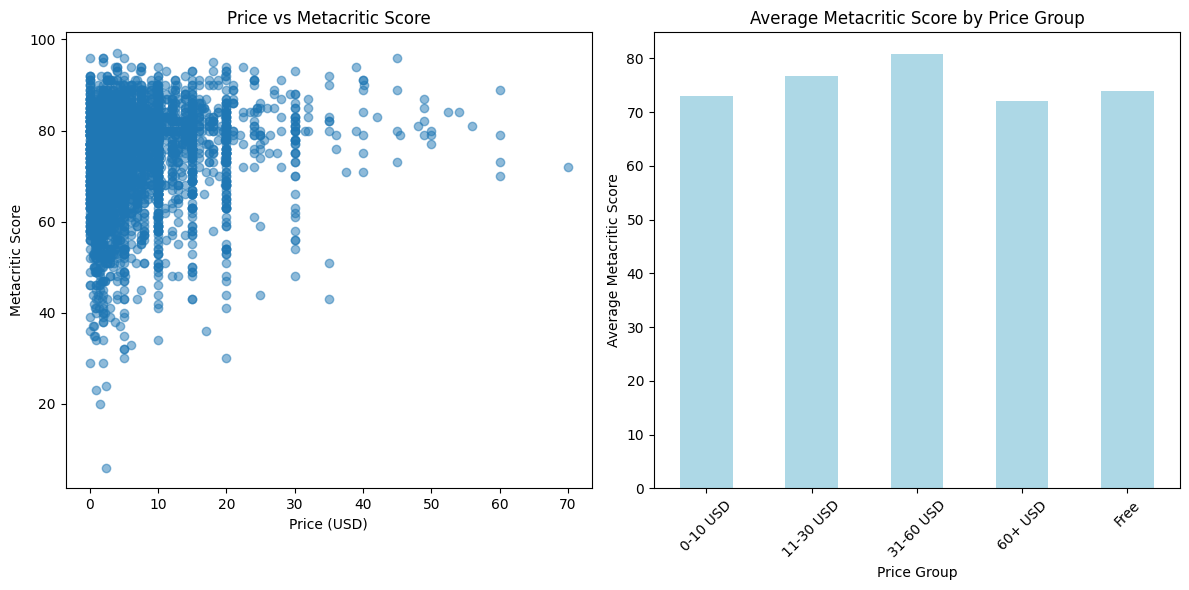


Average Scores by Price Range:
              mean  count    std
price_group                     
0-10 USD     73.09   3243  10.20
11-30 USD    76.73    664   9.88
31-60 USD    80.81     47   9.46
60+ USD      72.00      1    NaN
Free         73.92    230  10.85
Average Metacritic Scores by Game Genre:
                       mean_score  game_count  std_score
genres_list                                             
RPG                         74.85         943       9.66
Massively Multiplayer       74.72          75       9.39
Casual                      73.99         582       8.91
Adventure                   73.96        1976       9.82


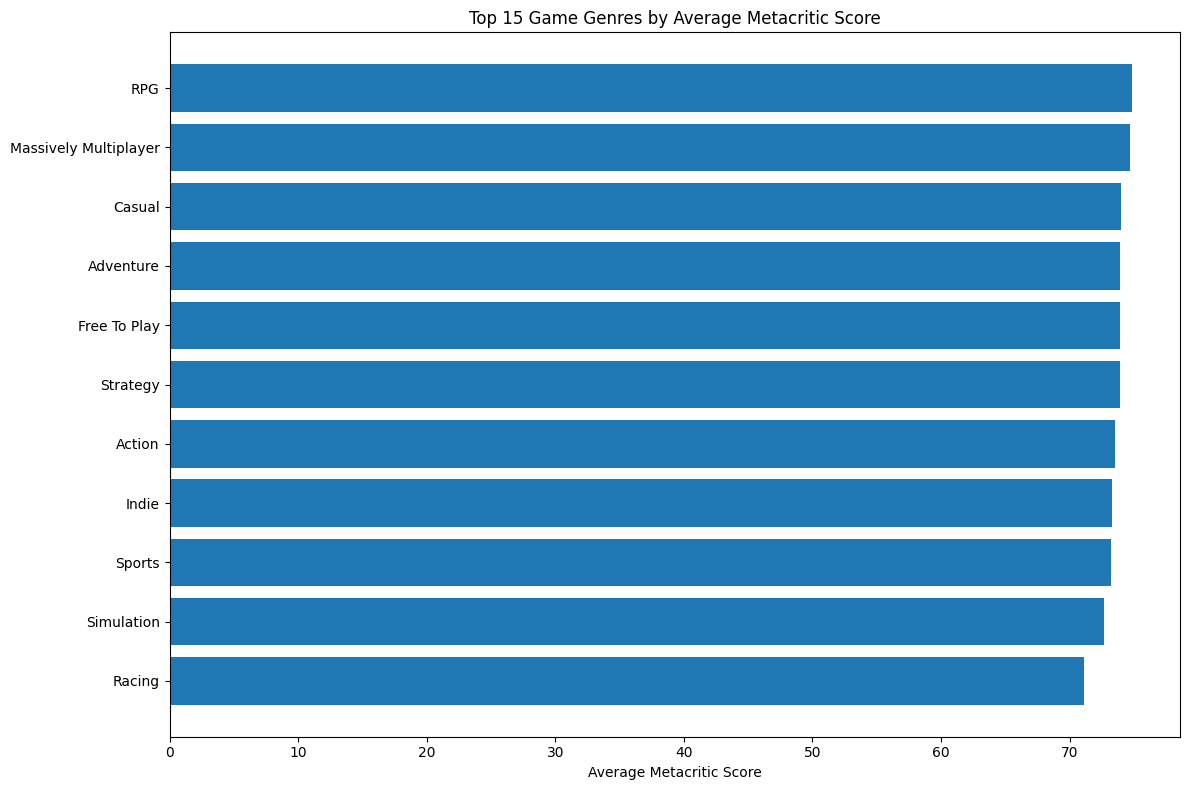

In [26]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(df_metacritic['Price'], df_metacritic['Metacritic score'], alpha=0.5)
plt.xlabel('Price (USD)')
plt.ylabel('Metacritic Score')
plt.title('Price vs Metacritic Score')

def price_group(price):
    if price == 0:
        return 'Free'
    elif price <= 10:
        return '0-10 USD'
    elif price <= 30:
        return '11-30 USD'
    elif price <= 60:
        return '31-60 USD'
    else:
        return '60+ USD'

df_metacritic['price_group'] = df_metacritic['Price'].apply(price_group)

plt.subplot(1, 2, 2)
price_score = df_metacritic.groupby('price_group')['Metacritic score'].mean().sort_index()
price_score.plot(kind='bar', color='lightblue')
plt.title('Average Metacritic Score by Price Group')
plt.xlabel('Price Group')
plt.ylabel('Average Metacritic Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nAverage Scores by Price Range:")
print(df_metacritic.groupby('price_group')['Metacritic score'].agg(['mean', 'count', 'std']).round(2))

def parse_list_string(s):
    if isinstance(s, str):
        return [genre.strip() for genre in s.split(',')]
    return []

df_metacritic['genres_list'] = df_metacritic['Genres'].apply(parse_list_string)

genres_expanded = df_metacritic.explode('genres_list')

genre_stats = genres_expanded.groupby('genres_list').agg({
    'Metacritic score': ['mean', 'count', 'std']
}).round(2)

genre_stats.columns = ['mean_score', 'game_count', 'std_score']
genre_stats = genre_stats[genre_stats['game_count'] >= 10].sort_values('mean_score', ascending=False)

print("Average Metacritic Scores by Game Genre:")
print(genre_stats.head(4))

plt.figure(figsize=(12, 8))
top_genres = genre_stats.head(15)
plt.barh(range(len(top_genres)), top_genres['mean_score'])
plt.yticks(range(len(top_genres)), top_genres.index)
plt.xlabel('Average Metacritic Score')
plt.title('Top 15 Game Genres by Average Metacritic Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Test de corrélation (linéaire) de Pearson
#correlation, p_value = stats.pearsonr(df_metacritic['Price'], df_metacritic['Metacritic score'])
#print(f"Pearson Correlation: {correlation:.3f}")
#print(f"P-value: {p_value:.3f}")
# Test de corrélation (monotone) de Spearman
#correlation_spearman, p_value_spearman = stats.spearmanr(df_metacritic['Price'], df_metacritic['Metacritic score'])
#print(f"Spearman Correlation: {correlation_spearman:.3f}")
#print(f"P-value: {p_value_spearman:.3f}")

There doesn't seem to be a link between the metacritic score and the price. (Pearson test tell us that there is one but it's not really big). Certain genres have a little better scores than others. Est-ce qu'on supprimerait pas les deux premiers graphiques et les tests en gardant les tableaux de données.

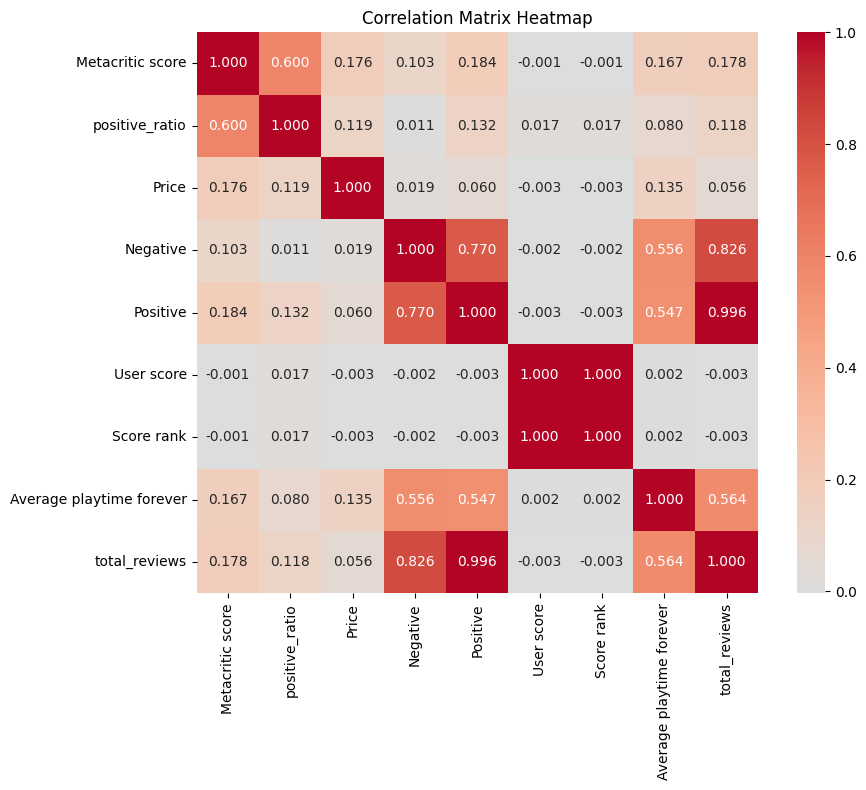

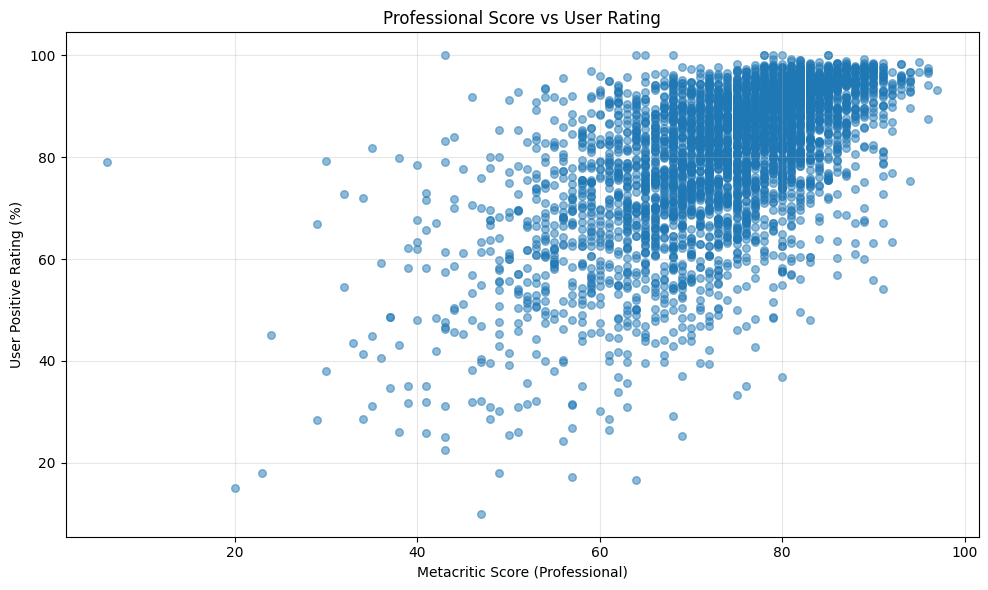

Pearson Correlation: 0.600
P-value: 0.000
Metacritic score    0
positive_ratio      0
dtype: int64


In [27]:
df_metacritic['total_reviews'] = df_metacritic['Positive'] + df_metacritic['Negative']
df_metacritic['positive_ratio'] = df_metacritic['Positive'] / df_metacritic['total_reviews']
df_metacritic['Score rank'] = df_metacritic['Score rank'].fillna(0)

correlation_matrix = df_metacritic[['Metacritic score', 'positive_ratio', 'Price', 
                                   'Negative', 'Positive', 'User score', 'Score rank', 'Average playtime forever', 'total_reviews']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df_metacritic['Metacritic score'], df_metacritic['positive_ratio']*100, 
            alpha=0.5, s=30)
plt.xlabel('Metacritic Score (Professional)')
plt.ylabel('User Positive Rating (%)')
plt.title('Professional Score vs User Rating')
plt.grid(True, alpha=0.3)

z = np.polyfit(df_metacritic['Metacritic score'], df_metacritic['positive_ratio']*100, 1)
p = np.poly1d(z)
plt.plot(df_metacritic['Metacritic score'], p(df_metacritic['Metacritic score']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

df_metacritic = df_metacritic.dropna(subset=['Metacritic score', 'positive_ratio'])
correlation, p_value = stats.pearsonr(df_metacritic['positive_ratio']*100, df_metacritic['Metacritic score'])
print(f"Pearson Correlation: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")
print(df_metacritic[['Metacritic score', 'positive_ratio']].isna().sum())

We can point out two things from these graph, the first one is that there seems to be a link between the time passed on a game and
the number of positive and negative votes it has (and not the total number of votes). We can interpret that players tend to play a lot before adding a vote? The second one show that the professionnal and players have roughly the same appealing on the games.

Coefficient de la droite (slope): 0.809
Ordonnée à l'origine (intercept): 21.078


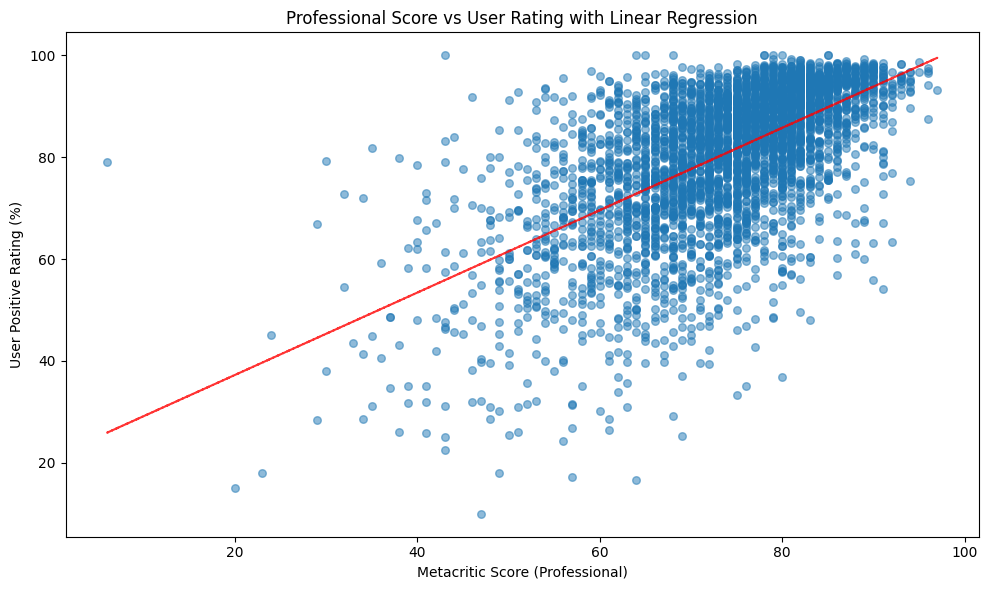

R² (coefficient de détermination): 0.360


In [28]:
X = df_metacritic[['Metacritic score']].values 
y = df_metacritic['positive_ratio'].values * 100 
model = LinearRegression()

model.fit(X, y)


slope = model.coef_[0]
intercept = model.intercept_

print(f"Coefficient de la droite (slope): {slope:.3f}")
print(f"Ordonnée à l'origine (intercept): {intercept:.3f}")
y_pred = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(df_metacritic['Metacritic score'], df_metacritic['positive_ratio']*100, alpha=0.5, s=30)
plt.xlabel('Metacritic Score (Professional)')
plt.ylabel('User Positive Rating (%)')
plt.title('Professional Score vs User Rating with Linear Regression')

plt.plot(df_metacritic['Metacritic score'], y_pred, color='red', linestyle='--', alpha=0.8)

plt.tight_layout()
plt.show()
r_squared = model.score(X, y)
print(f"R² (coefficient de détermination): {r_squared:.3f}")

The R² indicates that there is a linear link between the two variables but other variables are needed to complete the explanation of the variables.

In [29]:
#data3.loc[data3["User score"] != 0, ["User score", "Score rank"]]
tableau_contingence = pd.crosstab(data3['User score'], data3['Score rank'])
print(tableau_contingence)

Score rank  98.0   99.0   100.0
User score                     
37              1      0      0
46              2      0      0
51              1      1      0
53              1      0      0
55              1      0      0
57              0      1      0
60              0      1      0
61              0      1      0
63              0      1      0
65              0      1      0
66              0      1      0
68              0      2      0
69              0      1      0
71              0      1      0
73              0      1      0
76              0      1      0
77              0      2      0
78              0      1      0
80              0      1      1
82              0      1      0
83              0      1      0
84              0      2      0
87              0      0      1
88              0      0      1
92              0      0      1
94              0      0      1
95              0      0      1
96              0      0      1
97              0      0      1
100     

On se rend compte que le User score semble être équivalent au Score rank (0-60:98/55-85:99/85-100:100)


Playtime distribution:
Zero playtime: 87247 games (77.1%)
Positive playtime: 25871 games (22.9%)

=== High Playtime Games Analysis ===
High playtime games: 5169
Playtime threshold: 590 minutes (9.8 hours)
High playtime range: 591 - 3429544 minutes


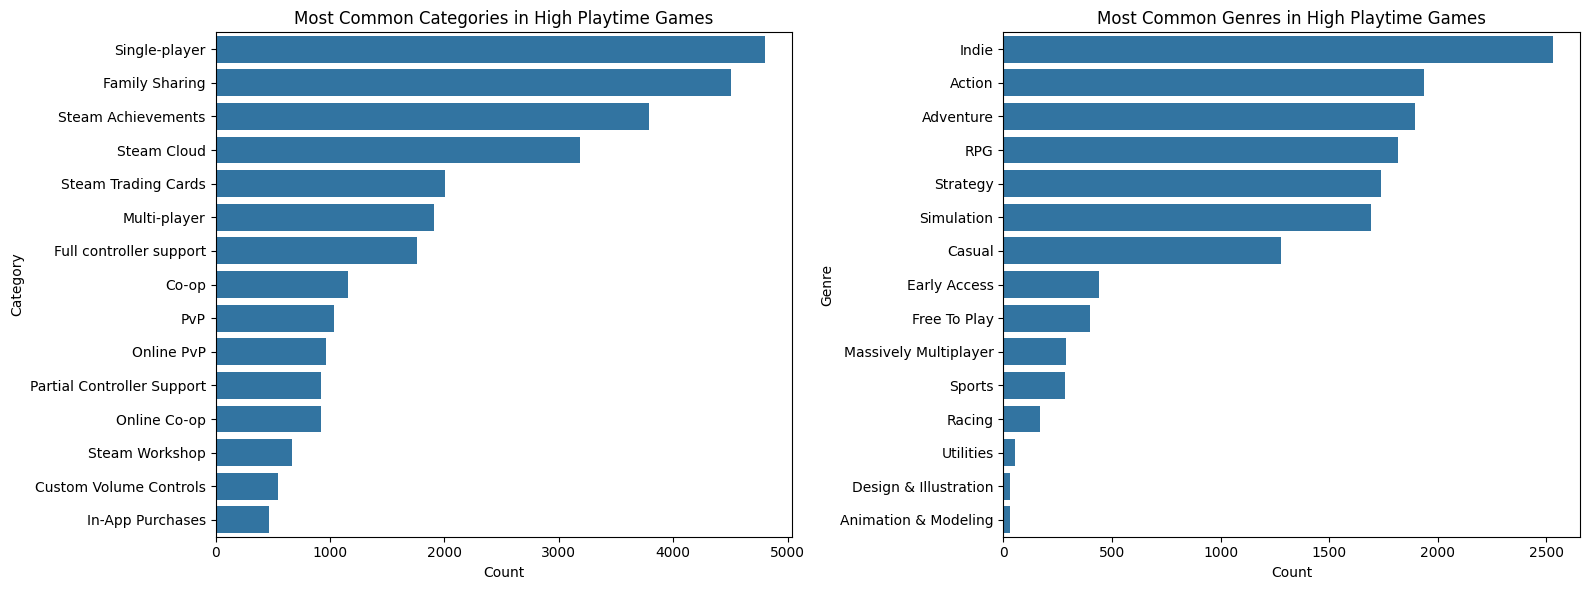

In [30]:
def preprocess_data(df):
    data3['total_votes'] = data3['Positive'] + data3['Negative']
    data3['positive_ratio'] = np.where(
        data3['total_votes'] > 0,
        data3['Positive'] / data3['total_votes'],
        0
    )
    
    data3['stickiness_ratio'] = np.where(
        data3['Average playtime forever'] > 0,
        data3['Average playtime two weeks'] / data3['Average playtime forever'],
        0
    )
    
    data3['retention_score'] = np.where(
        data3['Median playtime forever'] > 0,
        data3['Median playtime two weeks'] / data3['Median playtime forever'],
        0
    )
    
    data3['Release date'] = pd.to_datetime(data3['Release date'], errors='coerce', format='mixed')
    data3['release_year'] = data3['Release date'].dt.year
    
    def count_languages(lang_data):
        if isinstance(lang_data, list):
            return len(lang_data)
        elif isinstance(lang_data, str):
            try:
                if lang_data.startswith('[') and lang_data.endswith(']'):
                    lang_data = lang_data[1:-1]
                languages = [lang.strip().strip("'\"") for lang in lang_data.split(',')]
                return len([lang for lang in languages if lang])
            except:
                return 0
        else:
            return 0
    
    data3['supported_languages_count'] = data3['Supported languages'].apply(count_languages)
    data3['full_audio_languages_count'] = data3['Full audio languages'].apply(count_languages)
    
    def parse_list_data(list_data):
        if pd.isna(list_data):
            return []
        if isinstance(list_data, list):
            return list_data
        elif isinstance(list_data, str):
            try:
                if list_data.startswith('[') and list_data.endswith(']'):
                    list_data = list_data[1:-1].strip()
                    if not list_data:  
                        return []
                    
                    if list_data.startswith("'") or list_data.startswith('"'):
                        import re
                        items = re.findall(r"['\"]([^'\"]*)['\"]", list_data)
                        return [item.strip() for item in items if item.strip()]
                    else:
                        items = [item.strip() for item in list_data.split(',')]
                        return [item for item in items if item]
                else:
                    return [item.strip() for item in list_data.split(',') if item.strip()]
            except Exception:
                return []
        else:
            return []
    
    data3['categories_parsed'] = data3['Categories'].apply(parse_list_data)
    data3['genres_parsed'] = data3['Genres'].apply(parse_list_data)
    
    return df

data3 = preprocess_data(data3)

playtime_zero = len(data3[data3['Average playtime forever'] == 0])
playtime_positive = len(data3[data3['Average playtime forever'] > 0])
print(f"\nPlaytime distribution:")
print(f"Zero playtime: {playtime_zero} games ({(playtime_zero/len(data3))*100:.1f}%)")
print(f"Positive playtime: {playtime_positive} games ({(playtime_positive/len(data3))*100:.1f}%)")

valid_playtime_data = data3[data3['Average playtime forever'] > 0].copy()

if len(valid_playtime_data) == 0:
    print("Error: No valid playtime data!")
else:
    playtime_threshold = valid_playtime_data['Average playtime forever'].quantile(0.80)
    high_playtime = valid_playtime_data[valid_playtime_data['Average playtime forever'] > playtime_threshold].copy()

    print(f"\n=== High Playtime Games Analysis ===")
    print(f"High playtime games: {len(high_playtime)}")
    print(f"Playtime threshold: {playtime_threshold:.0f} minutes ({playtime_threshold/60:.1f} hours)")
    print(f"High playtime range: {high_playtime['Average playtime forever'].min():.0f} - {high_playtime['Average playtime forever'].max():.0f} minutes")

from collections import Counter

def flatten_categories(series):
    all_categories = []
    for categories in series:
        if isinstance(categories, list) and len(categories) > 0:
            all_categories.extend(categories)
    return Counter(all_categories)

high_playtime_categories = flatten_categories(high_playtime['categories_parsed'])
common_categories = pd.DataFrame(high_playtime_categories.most_common(15), 
                                columns=['Category', 'Count'])

high_playtime_genres = flatten_categories(high_playtime['genres_parsed'])
common_genres = pd.DataFrame(high_playtime_genres.most_common(15), 
                                columns=['Genre', 'Count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if len(common_categories) > 0:
    sns.barplot(data=common_categories, y='Category', x='Count', ax=axes[0])
    axes[0].set_title('Most Common Categories in High Playtime Games')
    axes[0].set_xlabel('Count')
else:
    axes[0].text(0.5, 0.5, 'No category data', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Category Distribution in High Playtime Games')

if len(common_genres) > 0:
    sns.barplot(data=common_genres, y='Genre', x='Count', ax=axes[1])
    axes[1].set_title('Most Common Genres in High Playtime Games')
    axes[1].set_xlabel('Count')
else:
    axes[1].text(0.5, 0.5, 'No genre data', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Genre Distribution in High Playtime Games')

plt.tight_layout()
plt.show()


There seems like the dataset has a lot of zeros in its different columns, which sparks questions about the veracity of our results...

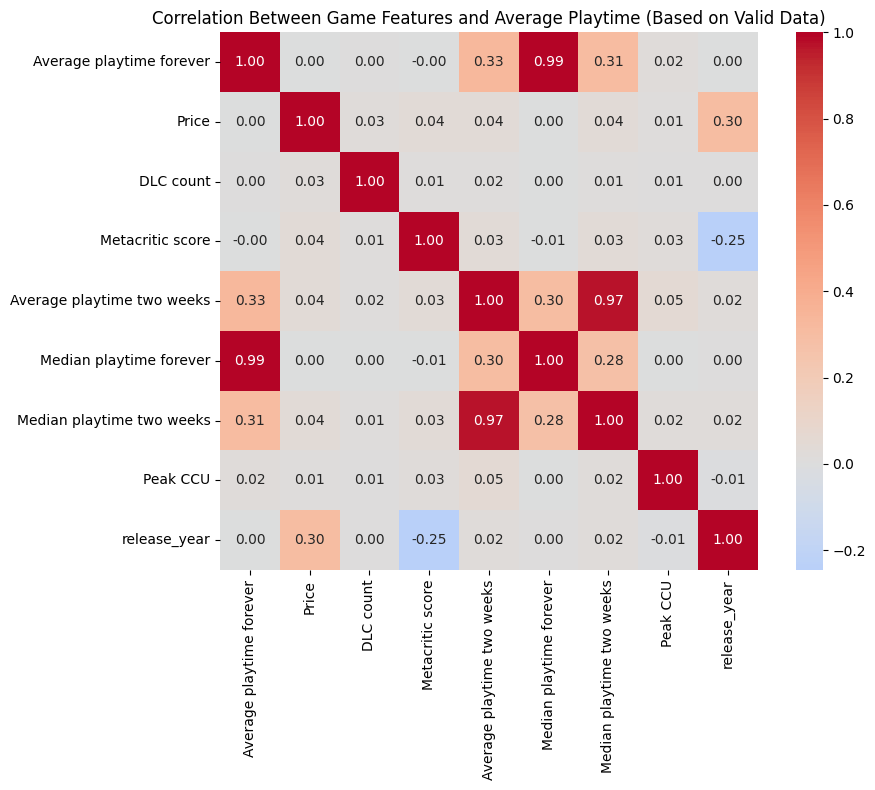

In [31]:
correlation_features = [
    'Average playtime forever', 'Price', 'DLC count', 'Metacritic score',
    'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks',
    'Peak CCU', 'release_year'
]

corr_data = valid_playtime_data[correlation_features].fillna(0)
corr_matrix = corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Correlation Between Game Features and Average Playtime (Based on Valid Data)')
plt.tight_layout()
plt.show()

(Cheap games aren't played a lot while expensive ones seems to be more played.) We see again a link between the price and the realease date
but it seems like there is also a negative correlation between the release date and the metacritic score (lots of games at 0 score).

===== Steam Rating Scale Standards =====
Steam Official Rating Scale:
95%-100%: Overwhelmingly Positive
90%-95%: Very Positive
80%-90%: Positive
70%-80%: Mostly Positive
40%-70%: Mixed
20%-40%: Mostly Negative
0%-20%: Negative
0%: No votes

===== Rating Distribution in Your Dataset =====


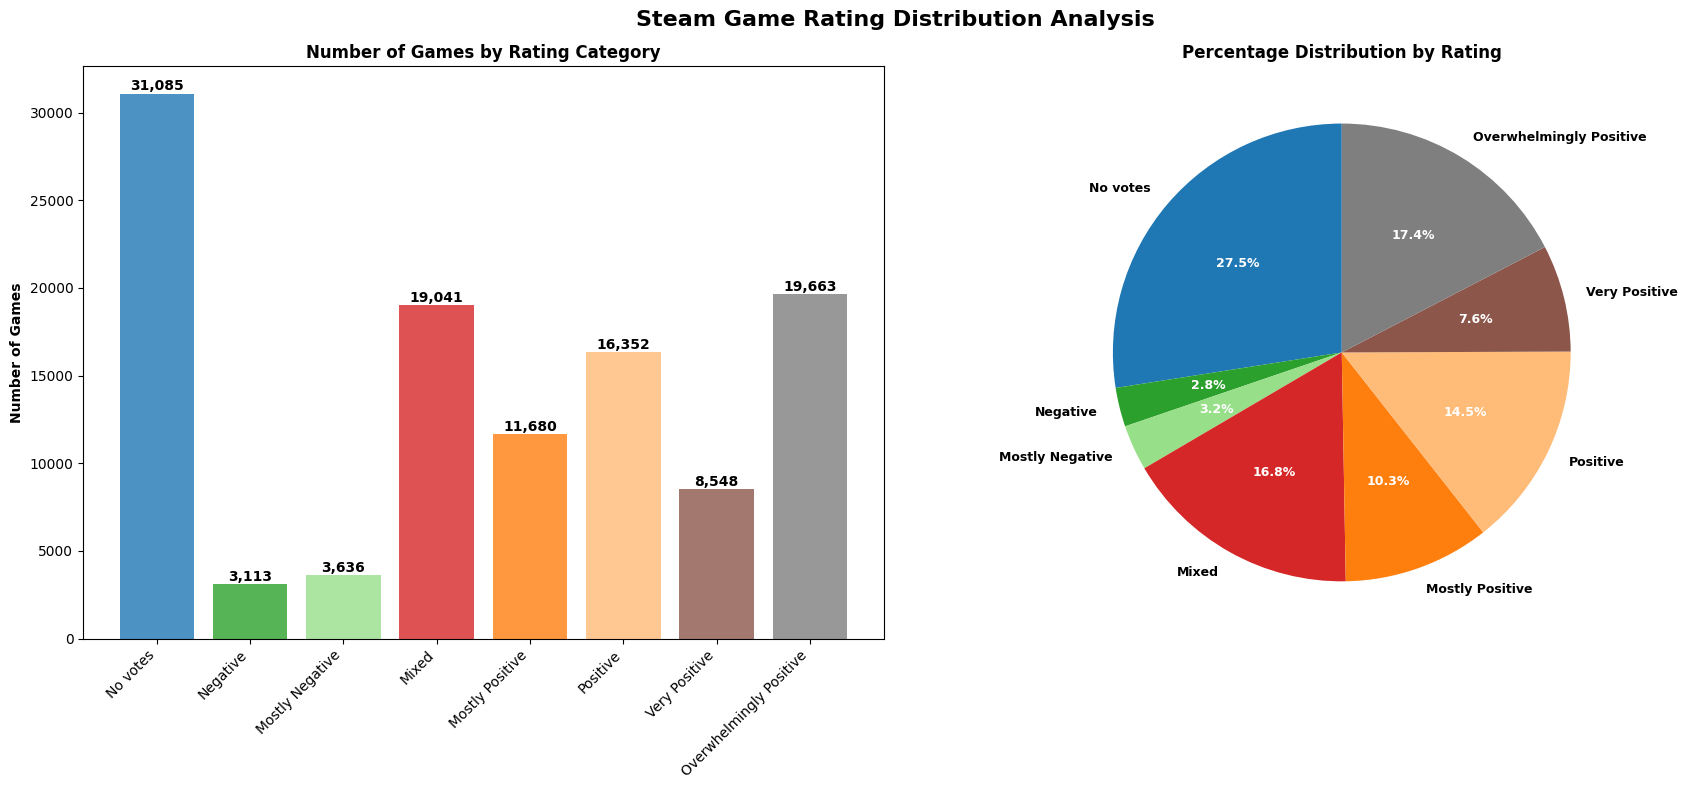


===== Detailed Analysis by Rating Category =====
Average Data by Rating Category:
                         Positive  Negative  total_votes  Price  \
steam_rating                                                      
No votes                     0.00      0.00         0.00   4.96   
Negative                     1.98     11.79        13.77   7.14   
Mostly Negative             40.32     90.75       131.07   6.64   
Mixed                      467.13    300.75       767.89   4.82   
Mostly Positive            980.98    307.50      1288.48   4.97   
Positive                  2682.08    443.19      3125.27   5.01   
Very Positive             3098.81    246.22      3345.03   5.30   
Overwhelmingly Positive   1752.01     57.31      1809.32   4.72   

                         positive_ratio  
steam_rating                             
No votes                            NaN  
Negative                           0.03  
Mostly Negative                    0.31  
Mixed                              0

/tmp/ipykernel_33608/3901286123.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_stats = data3.groupby('steam_rating').agg({


In [32]:
print("===== Steam Rating Scale Standards =====")

steam_rating_scale = {
    (0.95, 1.00): {"label": "Overwhelmingly Positive", "color": "#1f77b4"},
    (0.90, 0.95): {"label": "Very Positive", "color": "#2ca02c"},
    (0.80, 0.90): {"label": "Positive", "color": "#98df8a"},
    (0.70, 0.80): {"label": "Mostly Positive", "color": "#d62728"},
    (0.40, 0.70): {"label": "Mixed", "color": "#ff7f0e"},
    (0.20, 0.40): {"label": "Mostly Negative", "color": "#ffbb78"},
    (0.00, 0.20): {"label": "Negative", "color": "#8c564b"},
    (0.00, 0.00): {"label": "No votes", "color": "#7f7f7f"}
}

print("Steam Official Rating Scale:")
print("=" * 60)
for (min_val, max_val), info in steam_rating_scale.items():
    if min_val == max_val:
        print(f"{min_val*100:.0f}%: {info['label']}")
    else:
        print(f"{min_val*100:.0f}%-{max_val*100:.0f}%: {info['label']}")

print(f"\n===== Rating Distribution in Your Dataset =====")

data3['positive_ratio'] = data3['Positive'] / (data3['Positive'] + data3['Negative']).replace(0, np.nan)

def get_steam_rating(positive_ratio):
    if pd.isna(positive_ratio):
        return "No votes"
    
    for (min_val, max_val), info in steam_rating_scale.items():
        if min_val <= positive_ratio < max_val:
            return info["label"]
    
    if positive_ratio >= 0.95:
        return "Overwhelmingly Positive"
    return "No votes"

data3['steam_rating'] = data3['positive_ratio'].apply(get_steam_rating)

rating_order = ['No votes', 'Negative', 'Mostly Negative', 'Mixed', 'Mostly Positive','Positive','Very Positive','Overwhelmingly Positive']
data3['steam_rating'] = pd.Categorical(data3['steam_rating'], categories=rating_order, ordered=True)
rating_counts = data3['steam_rating'].value_counts(sort=False)
rating_percentages = data3['steam_rating'].value_counts(normalize=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Steam Game Rating Distribution Analysis', fontsize=16, fontweight='bold')

colors = [steam_rating_scale[(0.95, 1.00)]["color"], 
          steam_rating_scale[(0.90, 0.95)]["color"],
          steam_rating_scale[(0.80, 0.90)]["color"],
          steam_rating_scale[(0.70, 0.80)]["color"],
          steam_rating_scale[(0.40, 0.70)]["color"],
          steam_rating_scale[(0.20, 0.40)]["color"],
          steam_rating_scale[(0.00, 0.20)]["color"],
          steam_rating_scale[(0.00, 0.00)]["color"]]

bars = ax1.bar(rating_counts.index, rating_counts.values, color=colors, alpha=0.8)
ax1.set_title('Number of Games by Rating Category', fontweight='bold')
ax1.set_ylabel('Number of Games', fontweight='bold')

ax1.set_xticks(range(len(rating_counts.index)))
ax1.set_xticklabels(rating_counts.index, rotation=45, ha='right')

for bar, count in zip(bars, rating_counts.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5, f'{count:,}', 
             ha='center', va='bottom', fontweight='bold')

wedges, texts, autotexts = ax2.pie(rating_counts.values, labels=rating_counts.index, 
                                  autopct='%1.1f%%', colors=colors, startangle=90)
plt.setp(autotexts, size=9, weight="bold", color='white')
plt.setp(texts, size=9, weight="bold")
ax2.set_title('Percentage Distribution by Rating', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n===== Detailed Analysis by Rating Category =====")

rating_stats = data3.groupby('steam_rating').agg({
    'Positive': 'mean',
    'Negative': 'mean', 
    'total_votes': 'mean',
    'Price': 'mean',
    'positive_ratio': 'mean'
}).round(2)

print("Average Data by Rating Category:")
print(rating_stats)

print(f"\n===== Relationship Between Vote Count and Rating =====")
correlation = data3['total_votes'].corr(data3['positive_ratio'])
print(f"Correlation between vote count and positive ratio: {correlation:.3f}")

high_vote_games = data3[data3['total_votes'] > 1000]
if len(high_vote_games) > 0:
    print(f"\nRating Distribution of Highly Voted Games (>1000 votes):")
    high_vote_rating = high_vote_games['steam_rating'].value_counts()
    for rating, count in high_vote_rating.items():
        percentage = count / len(high_vote_games) * 100
        print(f"  {rating}: {count} games ({percentage:.1f}%)")

zero_votes = data3[data3['total_votes'] == 0]
print(f"\nGames with zero votes: {len(zero_votes):,} ({len(zero_votes)/len(data3)*100:.1f}%)")

A third of the dataset's games don't have any votes and a little more than half of the games have positive votes results. Something might seems strange at first: the overwhelmingly positive games have less positive votes average than the very positive ones or even the positive ones. We can suppose that the popular games are in the positive or very positive categories while "good" games without much players are in the overwhelmingly positive game's category.

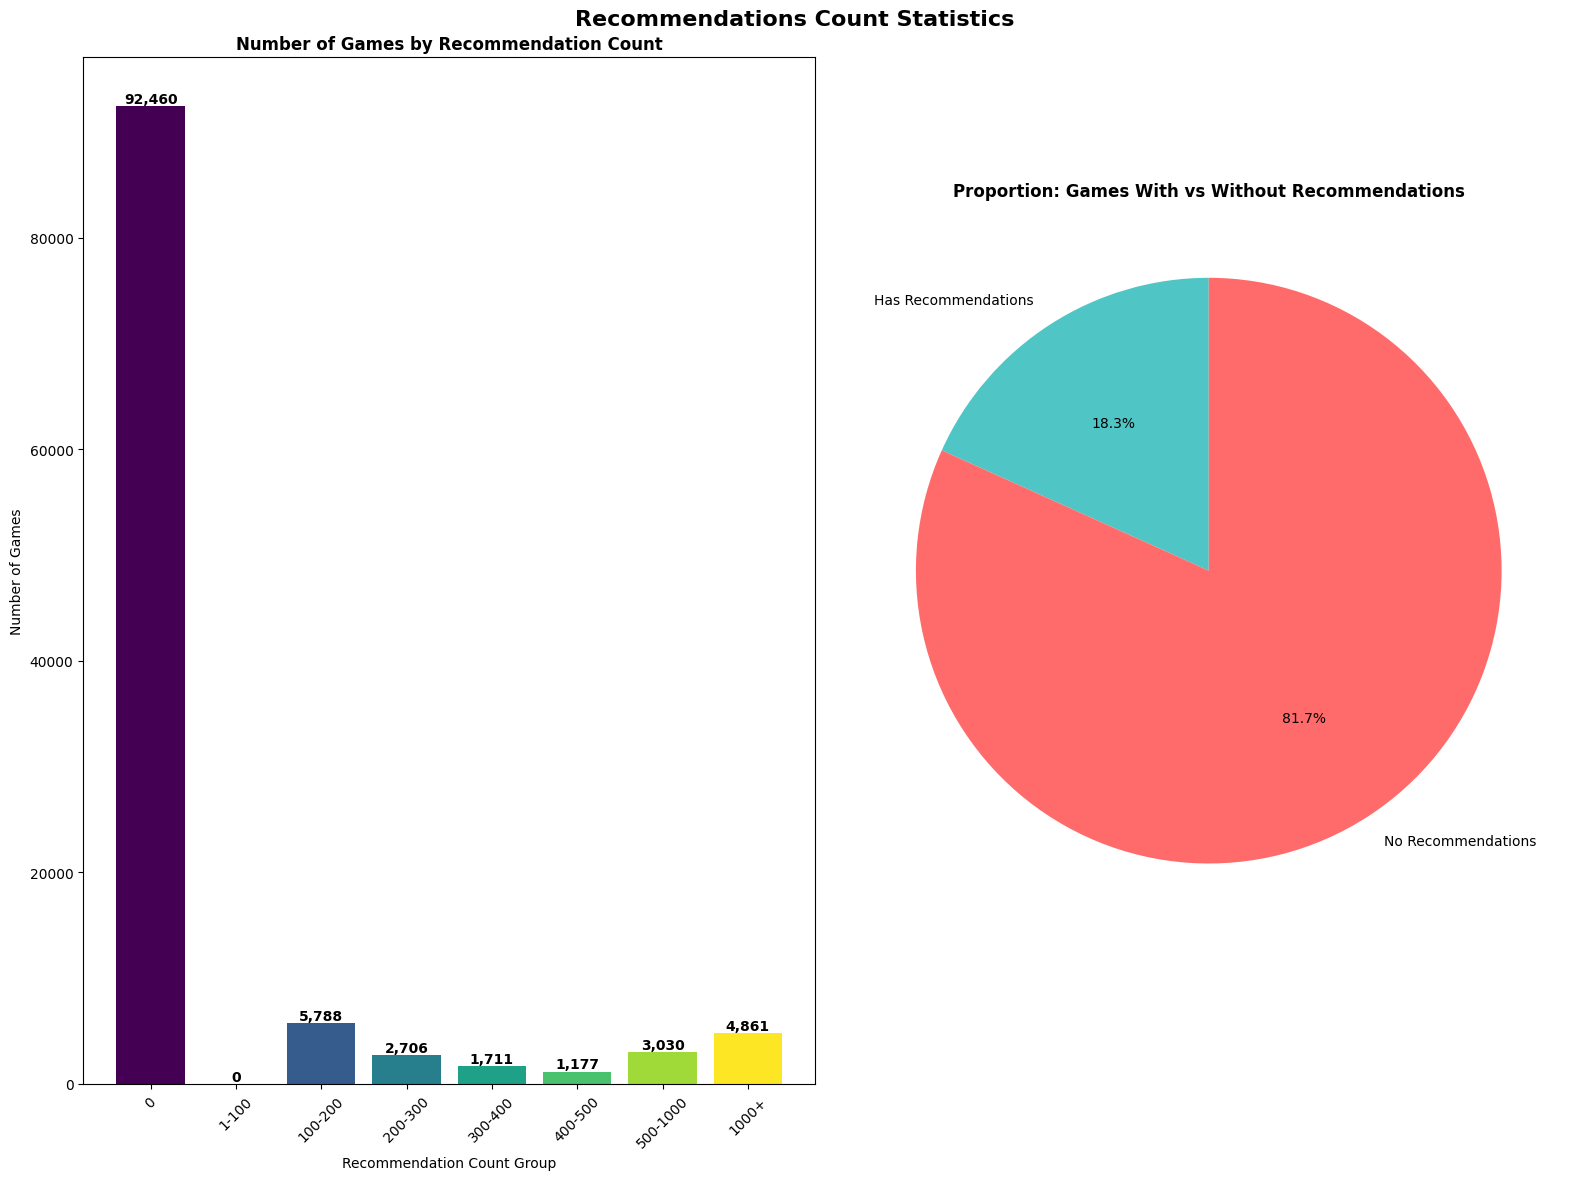

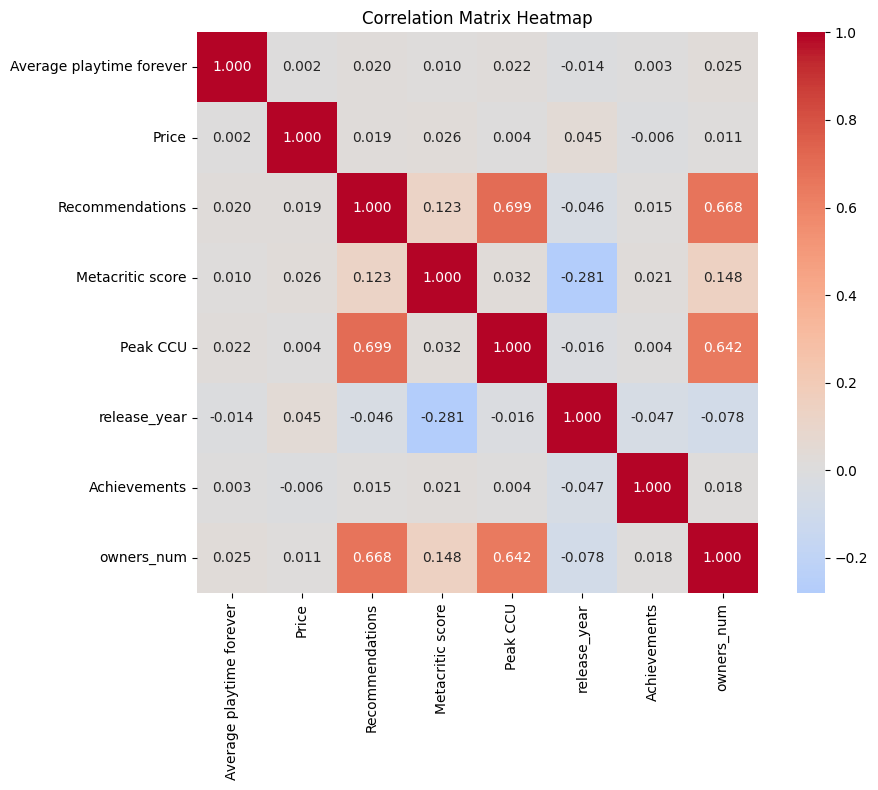

In [33]:
data3['recommendation_group'] = pd.cut(
    data3['Recommendations'],
    bins=[-1, 0, 100, 200, 300, 400, 500, 1000, 10000],
    labels=['0', '1-100', '100-200', '200-300', '300-400', '400-500', '500-1000', '1000+']
)

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(16, 12))
fig.suptitle('Recommendations Count Statistics', fontsize=16, fontweight='bold')

group_order = ['0', '1-100', '100-200', '200-300', '300-400', '400-500', '500-1000', '1000+']
group_counts = data3['recommendation_group'].value_counts().reindex(group_order)

bars = ax1.bar(group_order, group_counts, color=plt.cm.viridis(np.linspace(0, 1, len(group_order))))
ax1.set_title('Number of Games by Recommendation Count', fontweight='bold')
ax1.set_xlabel('Recommendation Count Group')
ax1.set_ylabel('Number of Games')
ax1.tick_params(axis='x', rotation=45)

for bar, count in zip(bars, group_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

has_recommendations = (data3['Recommendations'] > 0).sum()
no_recommendations= (data3['Recommendations'] == 0).sum()

labels = ['Has Recommendations', 'No Recommendations']
sizes = [has_recommendations, no_recommendations]
colors = ['#50c5c5', '#ff6b6b']

ax2.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Proportion: Games With vs Without Recommendations', fontweight='bold')
plt.tight_layout()
plt.show()

def parse_owners_range(x):
    if pd.isna(x):
        return None
    
    if isinstance(x, str):
        x = x.replace(',', '').strip()
        
        if '-' in x:
            low, high = x.split('-')
            return (float(low) + float(high)) / 2
        
        return float(x)
    
    return None


data3['owners_num'] = data3['Estimated owners'].apply(parse_owners_range)
correlation_features = data3[[
    'Average playtime forever', 'Price', 'Recommendations', 'Metacritic score',
     'Peak CCU', 'release_year', 'Achievements', 'owners_num'
]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_features, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

We can interpret the fact that there is no game which has between 0 and 100 recommendations: When one game has a recommendation, it gains naturally lots of recommendations after maybe because more and more people are begin to play it (see correlation matrix)

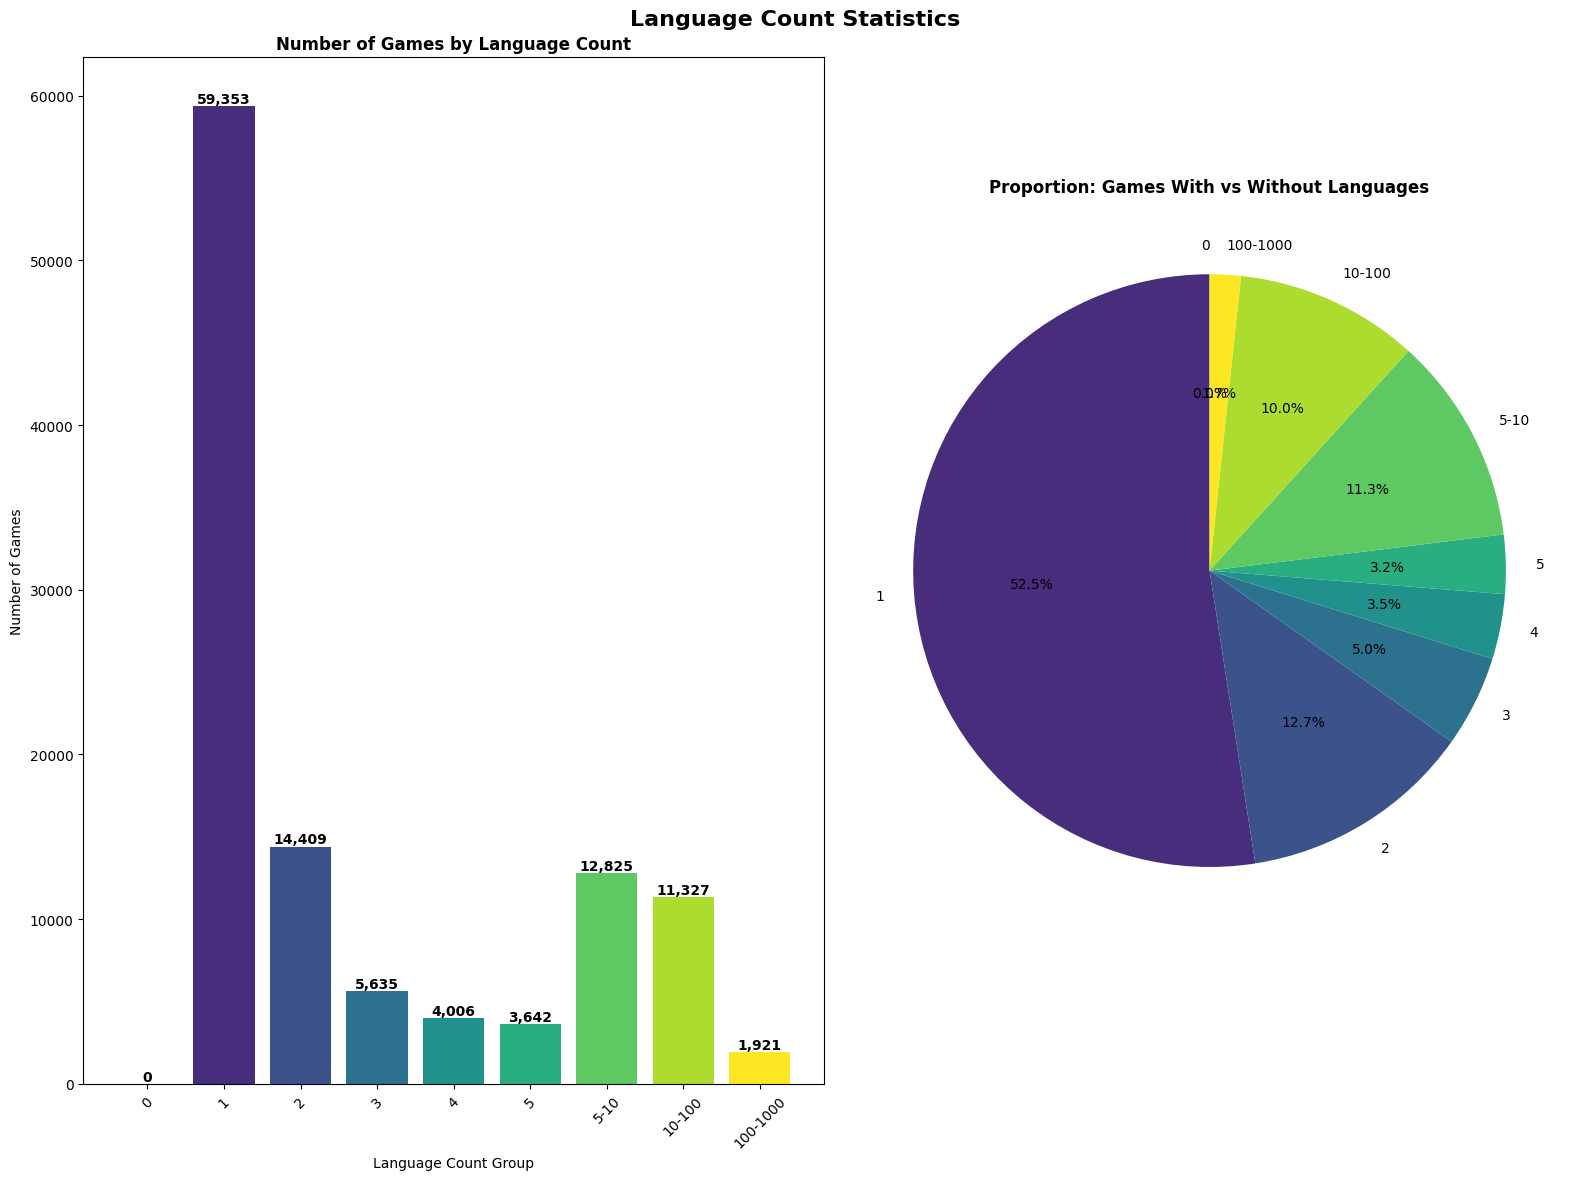

In [34]:
data3['num_languages'] = data3['Supported languages'].fillna('').apply(lambda x: len(str(x).split(',')))

data3['languages_group'] = pd.cut(
    data3['num_languages'],
    bins=[-1, 0, 1, 2, 3, 4, 5, 10, 100,1000],
    labels=['0', '1', '2', '3', '4', '5', '5-10', '10-100','100-1000']
)

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(16, 12))
fig.suptitle('Language Count Statistics', fontsize=16, fontweight='bold')

group_order = ['0', '1', '2', '3', '4', '5', '5-10', '10-100','100-1000']
group_counts = data3['languages_group'].value_counts().reindex(group_order)

bars = ax1.bar(group_order, group_counts, color=plt.cm.viridis(np.linspace(0, 1, len(group_order))))
ax1.set_title('Number of Games by Language Count', fontweight='bold')
ax1.set_xlabel('Language Count Group')
ax1.set_ylabel('Number of Games')
ax1.tick_params(axis='x', rotation=45)

for bar, count in zip(bars, group_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

labels = ['0', '1', '2', '3', '4', '5', '5-10', '10-100','100-1000']
sizes = data3['languages_group'].value_counts().reindex(labels).fillna(0)
colors = plt.cm.viridis(np.linspace(0, 1, len(labels)))

ax2.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Proportion: Games With vs Without Languages', fontweight='bold')
plt.tight_layout()
plt.show()



Most games have only one language

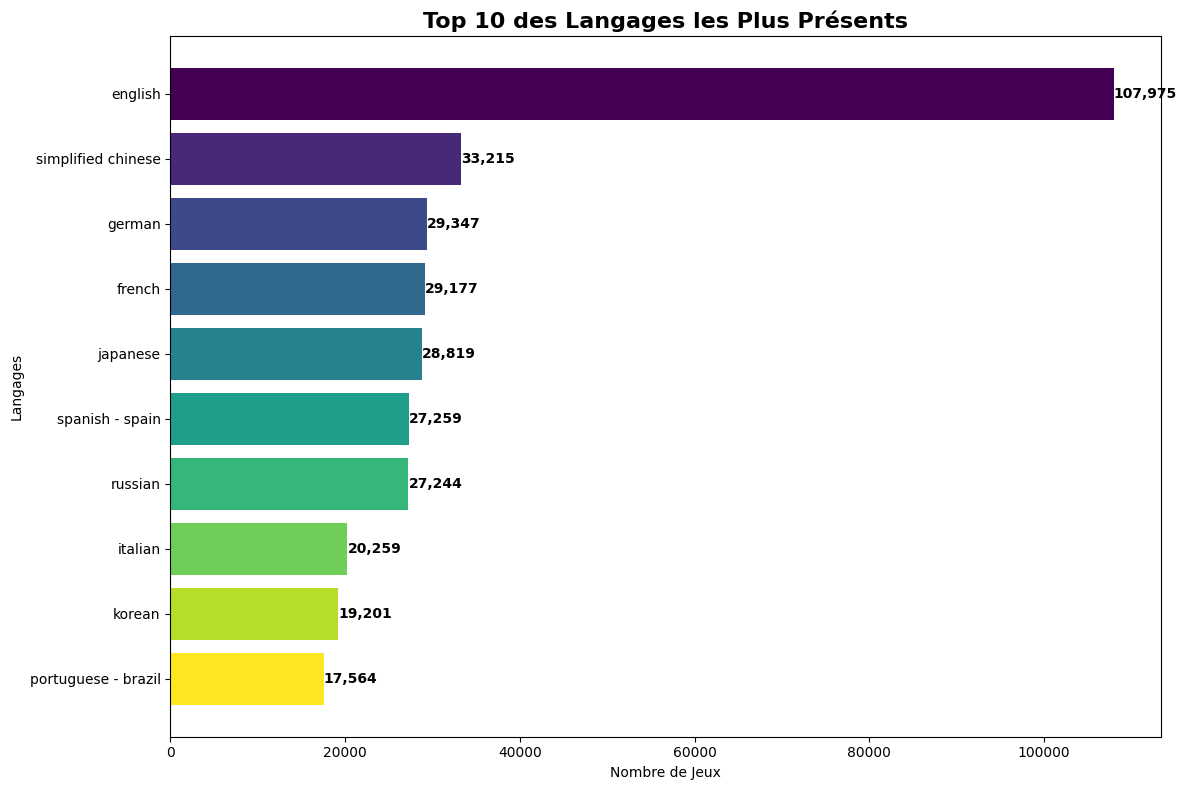

In [35]:
all_languages = data3['Supported languages'].dropna().apply(lambda x: x if x != '' else None)

all_languages = all_languages.dropna()

flat_languages = [lang.strip().lower().replace("'", "").replace("[", "").replace("]", "") for sublist in all_languages.str.split(',') for lang in sublist if lang.strip()]

language_counts = pd.Series(flat_languages).value_counts()

top_10_languages = language_counts.head(10)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top_10_languages.index, top_10_languages.values, color=plt.cm.viridis(np.linspace(0, 1, len(top_10_languages))))
ax.set_title('Top 10 des Langages les Plus Présents', fontsize=16, fontweight='bold')
ax.set_xlabel('Nombre de Jeux')
ax.set_ylabel('Langages')
ax.invert_yaxis()  

for index, value in enumerate(top_10_languages):
    ax.text(value, index, f'{value:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

English is the most used language in these games.